In [12]:
# ── Cell 1 : Imports ───────────────────────────────────────────────────────────
import json
import time
import datetime

import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from matplotlib.lines import Line2D

import liesel.model as lsl
import liesel.goose as gs
from tensorflow_probability.substrates.jax.experimental import distributions as tfde
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (16, 9)

In [13]:
# ── Cell 2 : Data Loading ──────────────────────────────────────────────────────

def load_sim_data(filepath):
    with open(filepath, "r") as f:
        raw = json.load(f)

    data = {
        "X":                jnp.array(raw["X"]),
        "y":                jnp.array(raw["y"]),
        "Z":                jnp.array(raw["Z"]),
        "unit_idx":         jnp.array(raw["unit_idx"]),
        "n_units":          int(raw["n_units"]),
        "n_params":         int(raw["n_params"]),
        "n_demos":          int(raw["n_demos"]),
        "K":                int(raw["K"]),
        "n_alts":           int(raw["n_alts"]),
        "TRUE_DELTA":       np.array(raw["TRUE_DELTA"]),
        "TRUE_BETA":        np.array(raw["TRUE_BETA"]),
        "TRUE_PVEC":        np.array(raw["TRUE_PVEC"]),
        "TRUE_MU_K":        np.array(raw["TRUE_MU_K"]),
        "TRUE_SIGMA_K":     np.array(raw["TRUE_SIGMA_K"]),
        "TRUE_INDICATORS":  np.array(raw["TRUE_INDICATORS"]),
    }
    return data


print("Loading simulated data...")
choice_data = load_sim_data("simulated_hmnl_data_3comp.json")  # ← only change

N  = choice_data["n_units"]
K  = choice_data["K"]
P  = choice_data["n_params"]
D  = choice_data["n_demos"]
A  = choice_data["n_alts"]

param_names = [f"Param_{j}" for j in range(P)]
demo_names  = [f"Demo_{d}"  for d in range(D)]

print(f"Units       : {N}")
print(f"Parameters  : {P}")
print(f"Alternatives: {A}")
print(f"Demos       : {D}")
print(f"Components  : {K}")
print(f"Total Obs   : {choice_data['y'].shape[0]}")

print("\n=== Ground Truth ===")
print("True pvec :", np.round(choice_data["TRUE_PVEC"], 4))
print("\nTrue Delta:")
display(pd.DataFrame(choice_data["TRUE_DELTA"],
                     index=demo_names, columns=param_names).round(4))
for k in range(K):
    print(f"\nTrue mu_k[{k}]:", np.round(choice_data["TRUE_MU_K"][k], 4))

Loading simulated data...
Units       : 300
Parameters  : 4
Alternatives: 4
Demos       : 2
Components  : 3
Total Obs   : 9000

=== Ground Truth ===
True pvec : [0.4  0.35 0.25]

True Delta:


,Param_0,Param_1,Param_2,Param_3
Demo_0,-0.5805,0.1696,-0.4485,0.2164
Demo_1,-0.1402,0.5073,0.4585,1.0594



True mu_k[0]: [ 2.  -1.  -1.  -0.5]

True mu_k[1]: [-1. -1. -1. -3.]

True mu_k[2]: [ 0.5  0.5  1.  -0.1]


In [14]:
# ── Cell 3 : Model Definition ──────────────────────────────────────────────────

def make_wishart(df, scale_tril):
    return tfd.WishartTriL(
        df=df,
        scale_tril=scale_tril,
        input_output_cholesky=True,
        validate_args=False
    )


def make_mvn_precision(loc, precision_factor):
    return tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=loc,
        precision_factor=tf.linalg.LinearOperatorLowerTriangular(precision_factor),
        validate_args=False
    )


def build_mixture_hmnl_model(
        data_dict,
        A_delta=0.01,
        a_mu=0.01,
        dirichlet_a=5.0
):
    """
    HMNL with mixture-of-normals heterogeneity.
    Prior structure matches bayesm::rhierMnlRwMixture.

        beta_i = Z[i] @ Delta + u_i,   u_i ~ N(mu_k, Sigma_k),  k ~ Categorical(pvec)

    Wishart:   Sigma_k^{-1} ~ W(nu, V^{-1}),  nu = n_params + 3,  V = nu * I
    Normal:    mu_k | Sigma_k ~ N(0, Sigma_k / a_mu)
    Normal:    Delta ~ N(0, (1/A_delta) * I)
    Dirichlet: pvec ~ Dir(dirichlet_a)
    """
    n_params = int(data_dict["n_params"])
    n_units  = int(data_dict["n_units"])
    K_comp   = int(data_dict["K"])
    has_Z    = data_dict.get("Z") is not None

    # ── Wishart prior ─────────────────────────────────────────────────────────
    nu          = float(n_params + 3)
    V           = nu * jnp.eye(n_params)
    Vinv_chol   = jnp.linalg.cholesky(jnp.linalg.inv(V))
    Vinv_chol_K = jnp.broadcast_to(Vinv_chol[None], (K_comp, n_params, n_params))

    # ── pvec ~ Dirichlet ──────────────────────────────────────────────────────
    pvec = lsl.Var.new_param(
        value=jnp.ones(K_comp) / K_comp,
        distribution=lsl.Dist(tfd.Dirichlet,
                               concentration=jnp.ones(K_comp) * dirichlet_a),
        name="pvec"
    )
    pvec_latent = pvec.transform(tfb.SoftmaxCentered(), name="pvec_latent")

    # ── Sigma_k^{-1} ~ Wishart via Cholesky ──────────────────────────────────
    sigma_inv_chol_k = lsl.Var.new_param(
        value=jnp.broadcast_to(jnp.eye(n_params)[None], (K_comp, n_params, n_params)),
        distribution=lsl.Dist(
            make_wishart,
            df=jnp.full(K_comp, nu),
            scale_tril=Vinv_chol_K
        ),
        name="sigma_inv_chol_k"
    )
    sigma_inv_chol_k_latent = sigma_inv_chol_k.transform(
        tfb.FillScaleTriL(), name="sigma_inv_chol_k_latent"
    )

    # ── mu_k | Sigma_k ~ N(0, Sigma_k / a_mu) ────────────────────────────────
    mu_prec_factor_k = lsl.Var.new_calc(
        lambda L: jnp.sqrt(a_mu) * L,
        L=sigma_inv_chol_k,
        name="mu_prec_factor_k"
    )
    mu_k = lsl.Var.new_param(
        value=jnp.zeros((K_comp, n_params)),
        distribution=lsl.Dist(
            make_mvn_precision,
            loc=jnp.zeros(n_params),
            precision_factor=mu_prec_factor_k
        ),
        name="mu_k"
    )

    # ── Delta ~ N(0, (1/A_delta) * I) ────────────────────────────────────────
    if has_Z:
        n_demos           = int(data_dict["Z"].shape[1])
        Z_var             = lsl.Var.new_obs(data_dict["Z"], name="Z_obs")
        Delta_prec_factor = jnp.sqrt(A_delta) * jnp.eye(n_params)

        Delta = lsl.Var.new_param(
            value=jnp.zeros((n_demos, n_params)),
            distribution=lsl.Dist(
                make_mvn_precision,
                loc=jnp.zeros(n_params),
                precision_factor=Delta_prec_factor
            ),
            name="Delta"
        )
        z_delta = lsl.Var.new_calc(
            lambda z, d: z @ d, z=Z_var, d=Delta, name="z_delta"
        )

    # ── beta_i location: Z[i] @ Delta + mu_k  (n_units, K, n_params) ─────────
    if has_Z:
        beta_loc = lsl.Var.new_calc(
            lambda zd, mu: zd[:, None, :] + mu[None, :, :],
            zd=z_delta, mu=mu_k,
            name="beta_loc"
        )
    else:
        beta_loc = lsl.Var.new_calc(
            lambda mu: jnp.broadcast_to(mu[None, :, :], (n_units, K_comp, n_params)),
            mu=mu_k,
            name="beta_loc"
        )

    def make_beta_mixture(pvec, locs, precision_factors):
        return tfd.MixtureSameFamily(
            mixture_distribution=tfd.Categorical(probs=pvec),
            components_distribution=tfde.MultivariateNormalPrecisionFactorLinearOperator(
                loc=locs,
                precision_factor=tf.linalg.LinearOperatorLowerTriangular(precision_factors[None])
            )
        )

    beta_i = lsl.Var.new_param(
        value=jnp.zeros((n_units, n_params)),
        distribution=lsl.Dist(
            make_beta_mixture,
            pvec=pvec,
            locs=beta_loc,
            precision_factors=sigma_inv_chol_k
        ),
        name="beta_i"
    )

    # ── Likelihood ────────────────────────────────────────────────────────────
    X_var         = lsl.Var.new_obs(data_dict["X"],        name="X_obs")
    idx_var       = lsl.Var.new_obs(data_dict["unit_idx"], name="idx_obs")
    beta_expanded = lsl.Var.new_calc(
        lambda b, idx: b[idx], b=beta_i, idx=idx_var, name="beta_expanded"
    )
    logits = lsl.Var.new_calc(
        lambda x, b: jnp.einsum("nij,nj->ni", x, b),
        x=X_var, b=beta_expanded,
        name="logits"
    )
    y_var = lsl.Var.new_obs(
        data_dict["y"],
        distribution=lsl.Dist(tfd.Categorical, logits=logits),
        name="y"
    )

    return lsl.Model([y_var])


print("Building 3-component mixture HMNL model...")
hmnl_model = build_mixture_hmnl_model(
    choice_data, A_delta=0.01, a_mu=0.01, dirichlet_a=5.0
)
print("Model built successfully.")

Building 3-component mixture HMNL model...
Model built successfully.


c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\.venv\Lib\site-packages\jax\_src\numpy\array_methods.py:122: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


In [15]:
# ── Cell 4 : Inference ────────────────────────────────────────────────────────

def run_mixture_inference(model, data_dict, chains=4, warmup=1000,
                          posterior=5000, seed=123):
    has_Z = data_dict.get("Z") is not None
    eb = gs.EngineBuilder(seed=seed, num_chains=chains)
    eb.set_model(gs.LieselInterface(model))
    eb.set_initial_values(model.state)

    eb.add_kernel(gs.NUTSKernel(
        ["pvec_latent", "mu_k", "sigma_inv_chol_k_latent"],
        mm_diag=False
    ))

    if has_Z:
        eb.add_kernel(gs.NUTSKernel(["Delta"]))

    eb.add_kernel(gs.NUTSKernel(["beta_i"], mm_diag=True))

    eb.set_duration(warmup_duration=warmup, posterior_duration=posterior)

    print("Starting NUTS Sampling — 3-Component Mixture HMNL...")
    engine = eb.build()
    engine.sample_all_epochs()
    return engine.get_results(), engine.get_results().get_posterior_samples()


start_time = time.time()
mcmc_results, posterior_samples = run_mixture_inference(
    hmnl_model, choice_data, chains=4, warmup=1000, posterior=2500, seed=123
)
print(f"Sampling finished in "
      f"{datetime.timedelta(seconds=int(time.time() - start_time))}")

liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...


Starting NUTS Sampling — 3-Component Mixture HMNL...


liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:27<00:00,  9.10s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 3, 4, 6, 4 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 1, 1, 1, 0 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 2, 2, 2, 2 / 75 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 463.41chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 0, 1, 1, 1 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 1, 1, 1, 2 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 1, 1, 1, 1 / 25 transitions
liesel.goose.e

Sampling finished in 0:12:26


In [16]:
# ── Cell 5 : Label Switching — Pivotal Reordering Algorithm ───────────────────

def pra(xi_star, xi_draws):
    m, K_c, J = xi_draws.shape
    perms     = np.empty((m, K_c), dtype=int)
    relabeled = np.empty_like(xi_draws)
    for t in range(m):
        cost = np.sum(
            (xi_star[:, None, :] - xi_draws[t, None, :, :]) ** 2, axis=-1
        )
        _, perms[t] = linear_sum_assignment(cost)
        relabeled[t] = xi_draws[t, perms[t], :]
    return perms, relabeled


def apply_permutations(draws, perms):
    relabeled = np.empty_like(draws)
    for t in range(perms.shape[0]):
        relabeled[t] = draws[t, perms[t]]
    return relabeled


def resolve_label_switching(samples_dict, pivot_chain_idx=0):
    print("\nStarting Pivotal Reordering Algorithm (PRA)...")
    mu                           = samples_dict["mu_k"]
    n_chains, n_draws, K_c, n_p = mu.shape
    m                            = n_chains * n_draws

    mu_flat  = mu.reshape(m, K_c, n_p)
    xi_star  = np.mean(mu[pivot_chain_idx], axis=0)
    perms, relabeled_mu_flat = pra(xi_star, mu_flat)

    sorted_samples         = samples_dict.copy()
    sorted_samples["mu_k"] = relabeled_mu_flat.reshape(n_chains, n_draws, K_c, n_p)

    # Sigma
    sigma      = samples_dict["sigma_inv_chol_k_latent"]
    s_shape    = sigma.shape
    sigma_flat = sigma.reshape(m, K_c, *s_shape[3:])
    sorted_samples["sigma_inv_chol_k_latent"] = apply_permutations(
        sigma_flat, perms
    ).reshape(s_shape)

    # pvec: latent → simplex → permute
    pvec_simplex = np.array(
        tfb.SoftmaxCentered().forward(samples_dict["pvec_latent"])
    )
    pvec_flat = pvec_simplex.reshape(m, K_c)
    sorted_samples["pvec"] = apply_permutations(
        pvec_flat, perms
    ).reshape(n_chains, n_draws, K_c)

    print("Label switching resolved — all chains aligned.")
    return sorted_samples


posterior_samples_sorted = resolve_label_switching(
    posterior_samples, pivot_chain_idx=0
)


Starting Pivotal Reordering Algorithm (PRA)...
Label switching resolved — all chains aligned.



=== MCMC Convergence Summary ===


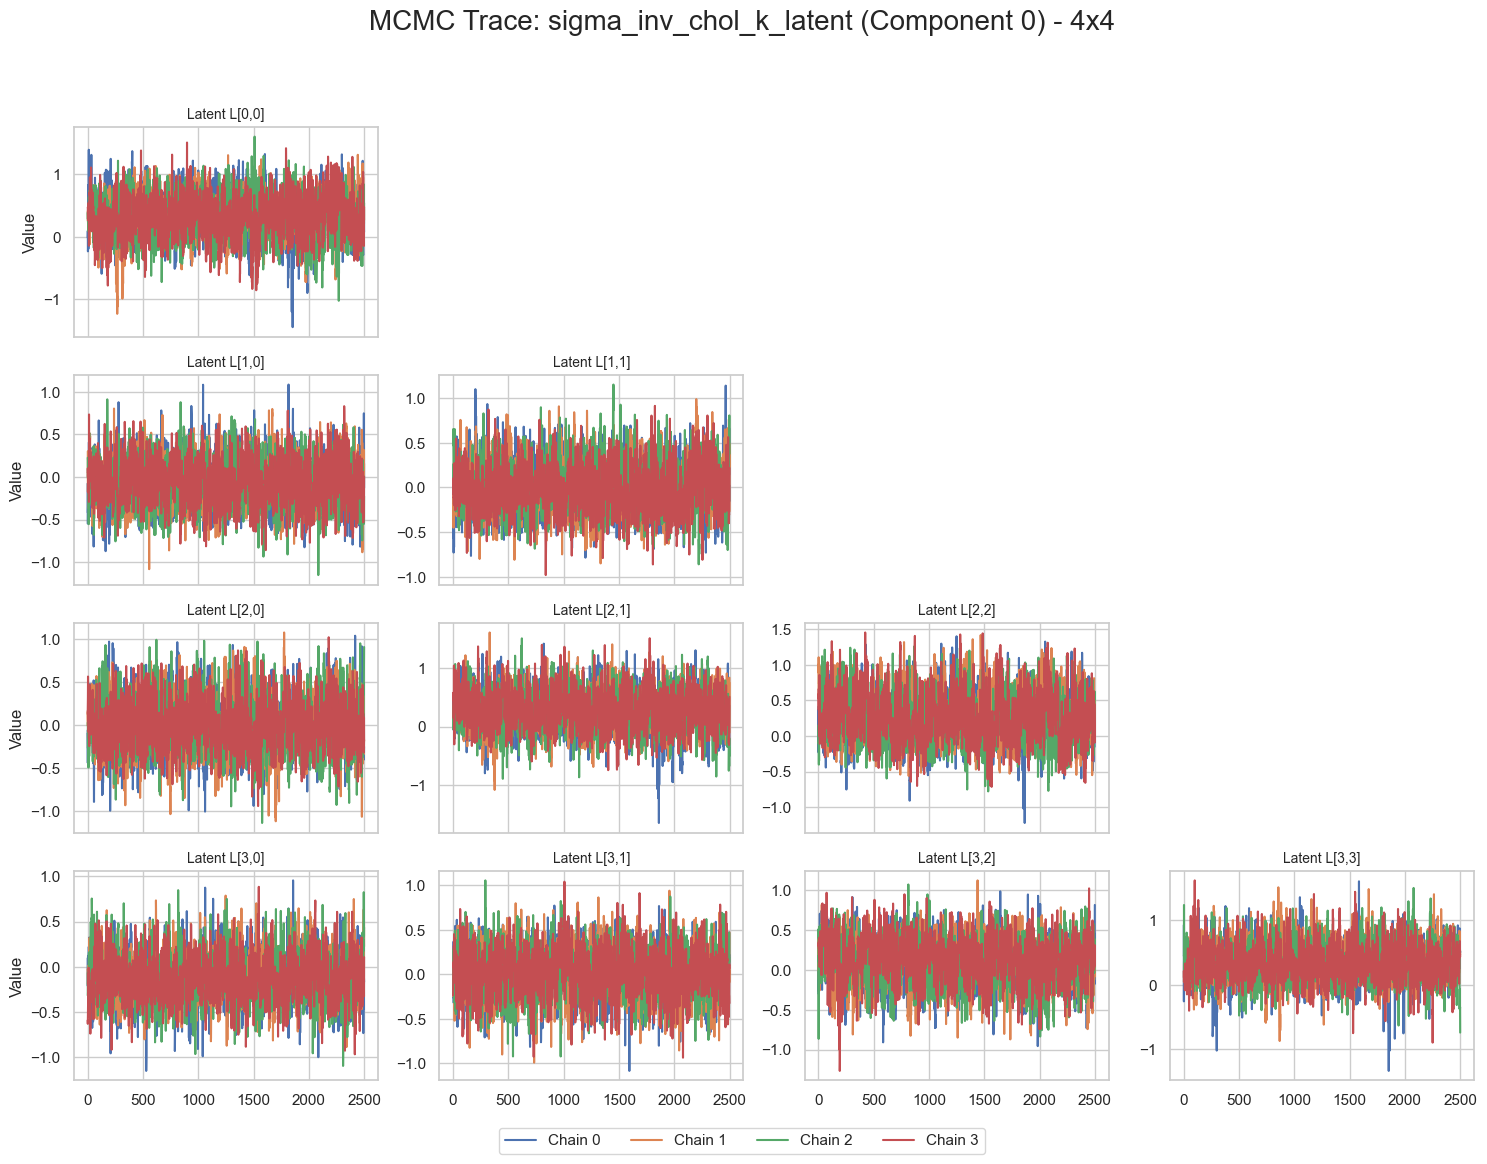

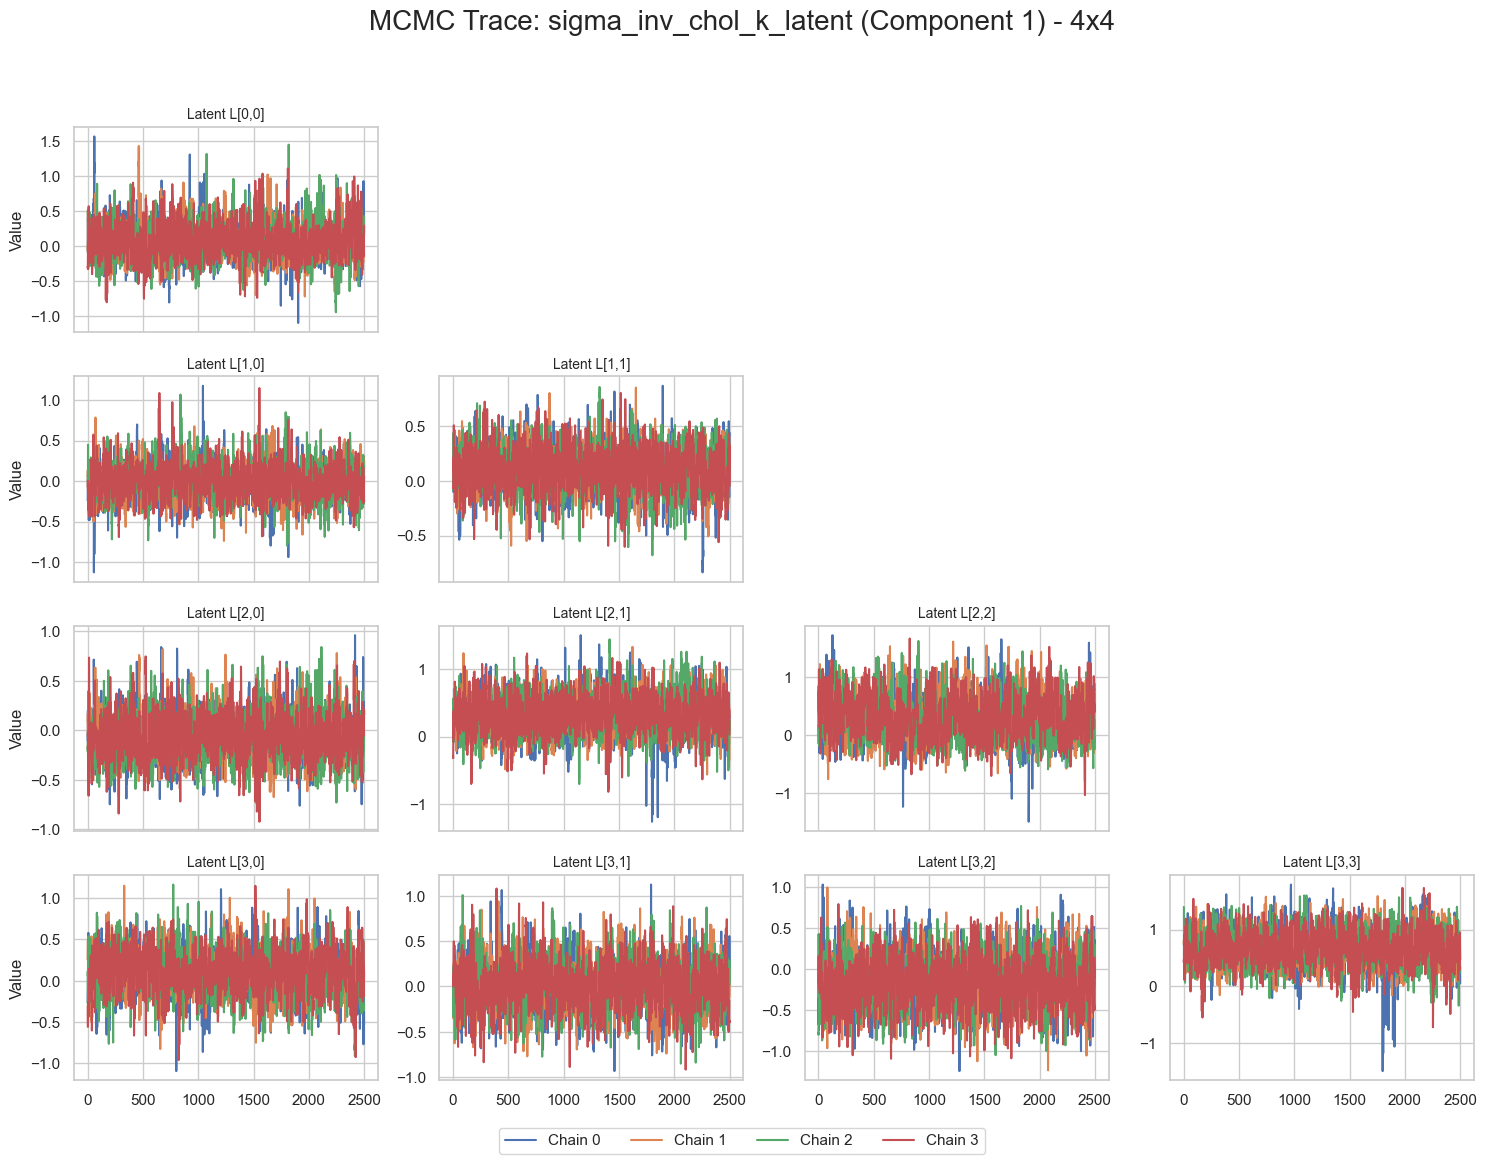

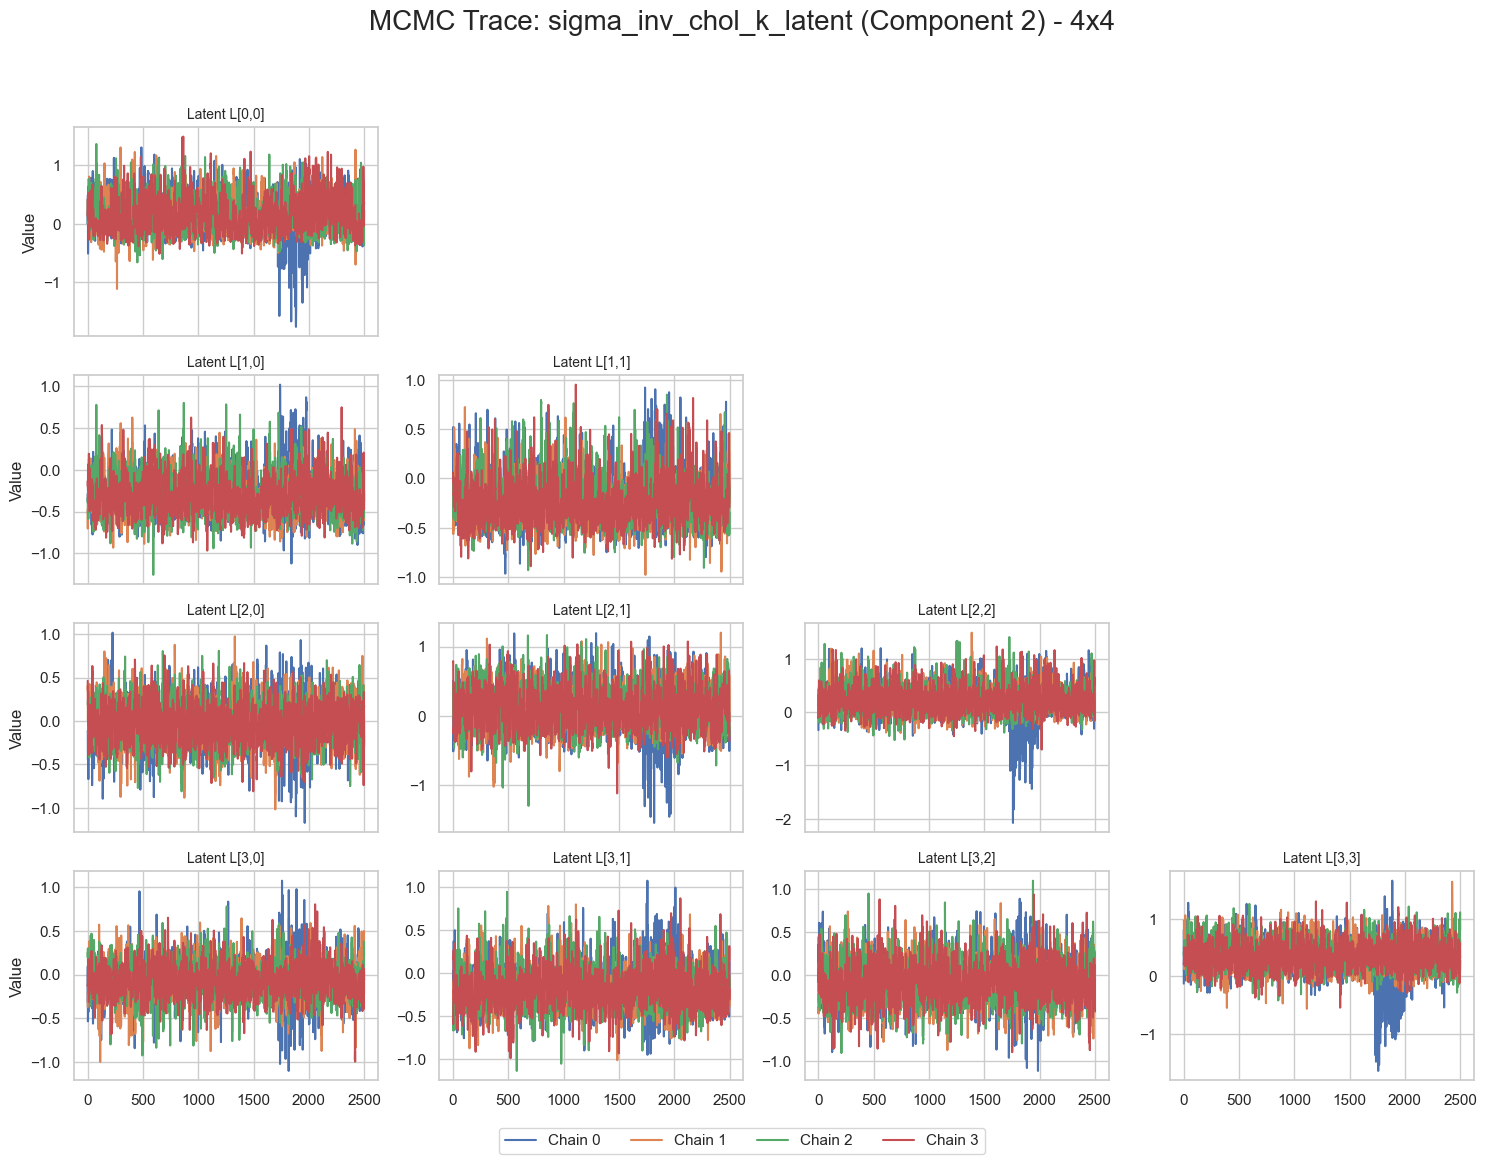


Recovering Covariance Matrices (Sigma_k) from sorted samples...


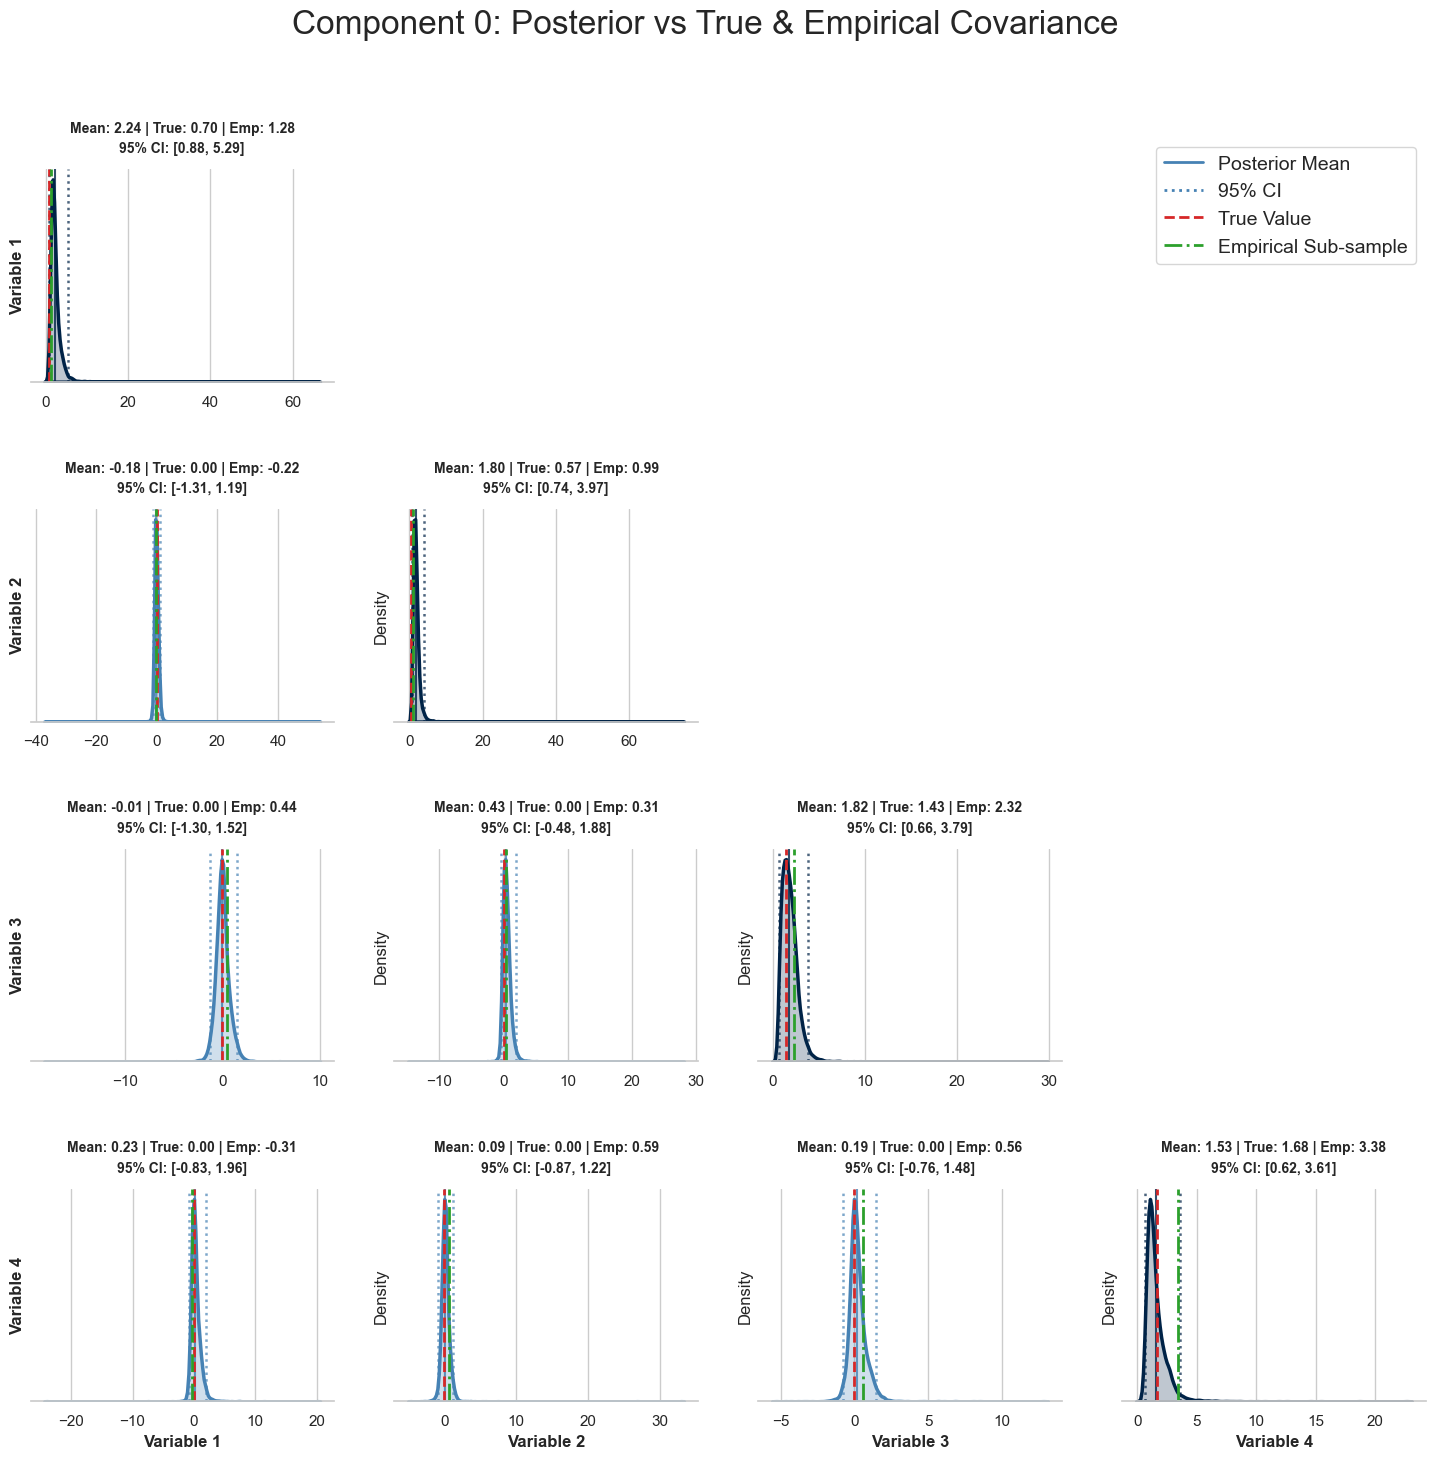

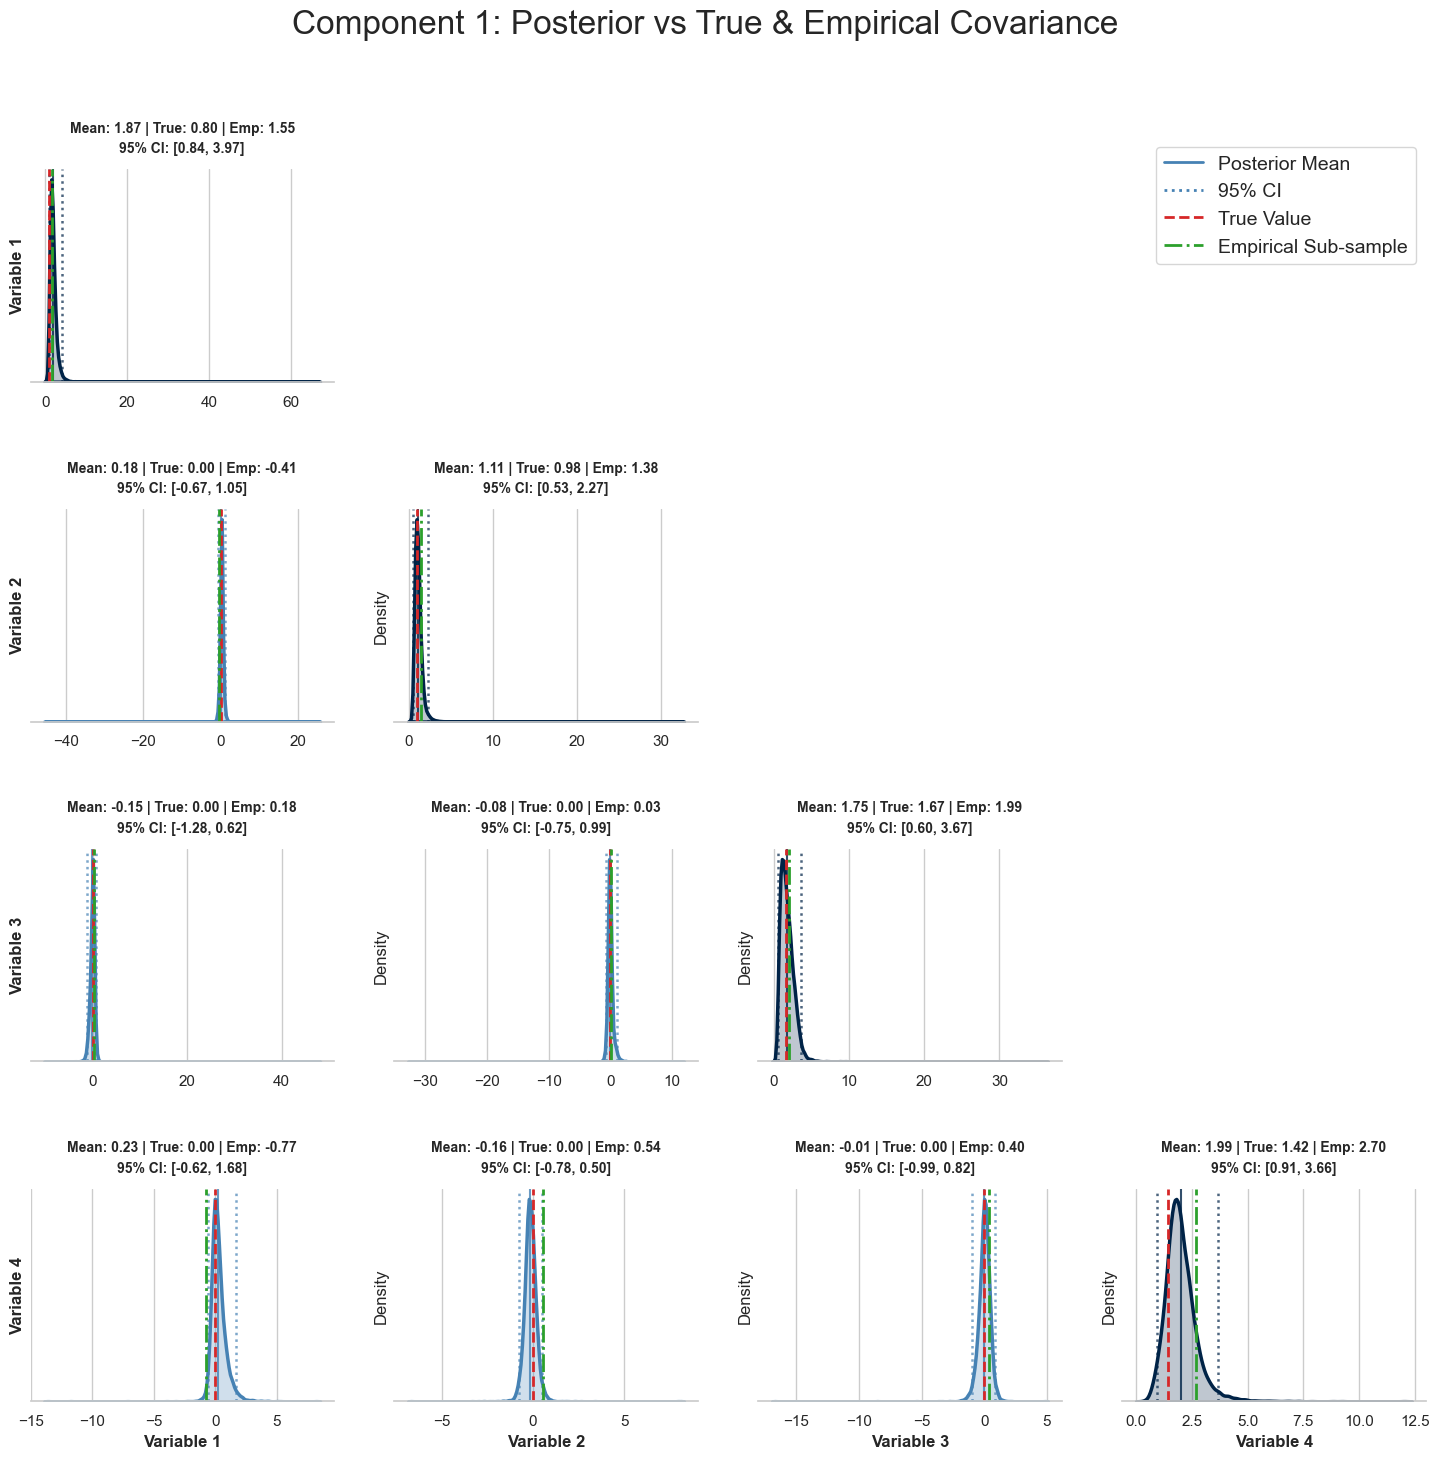

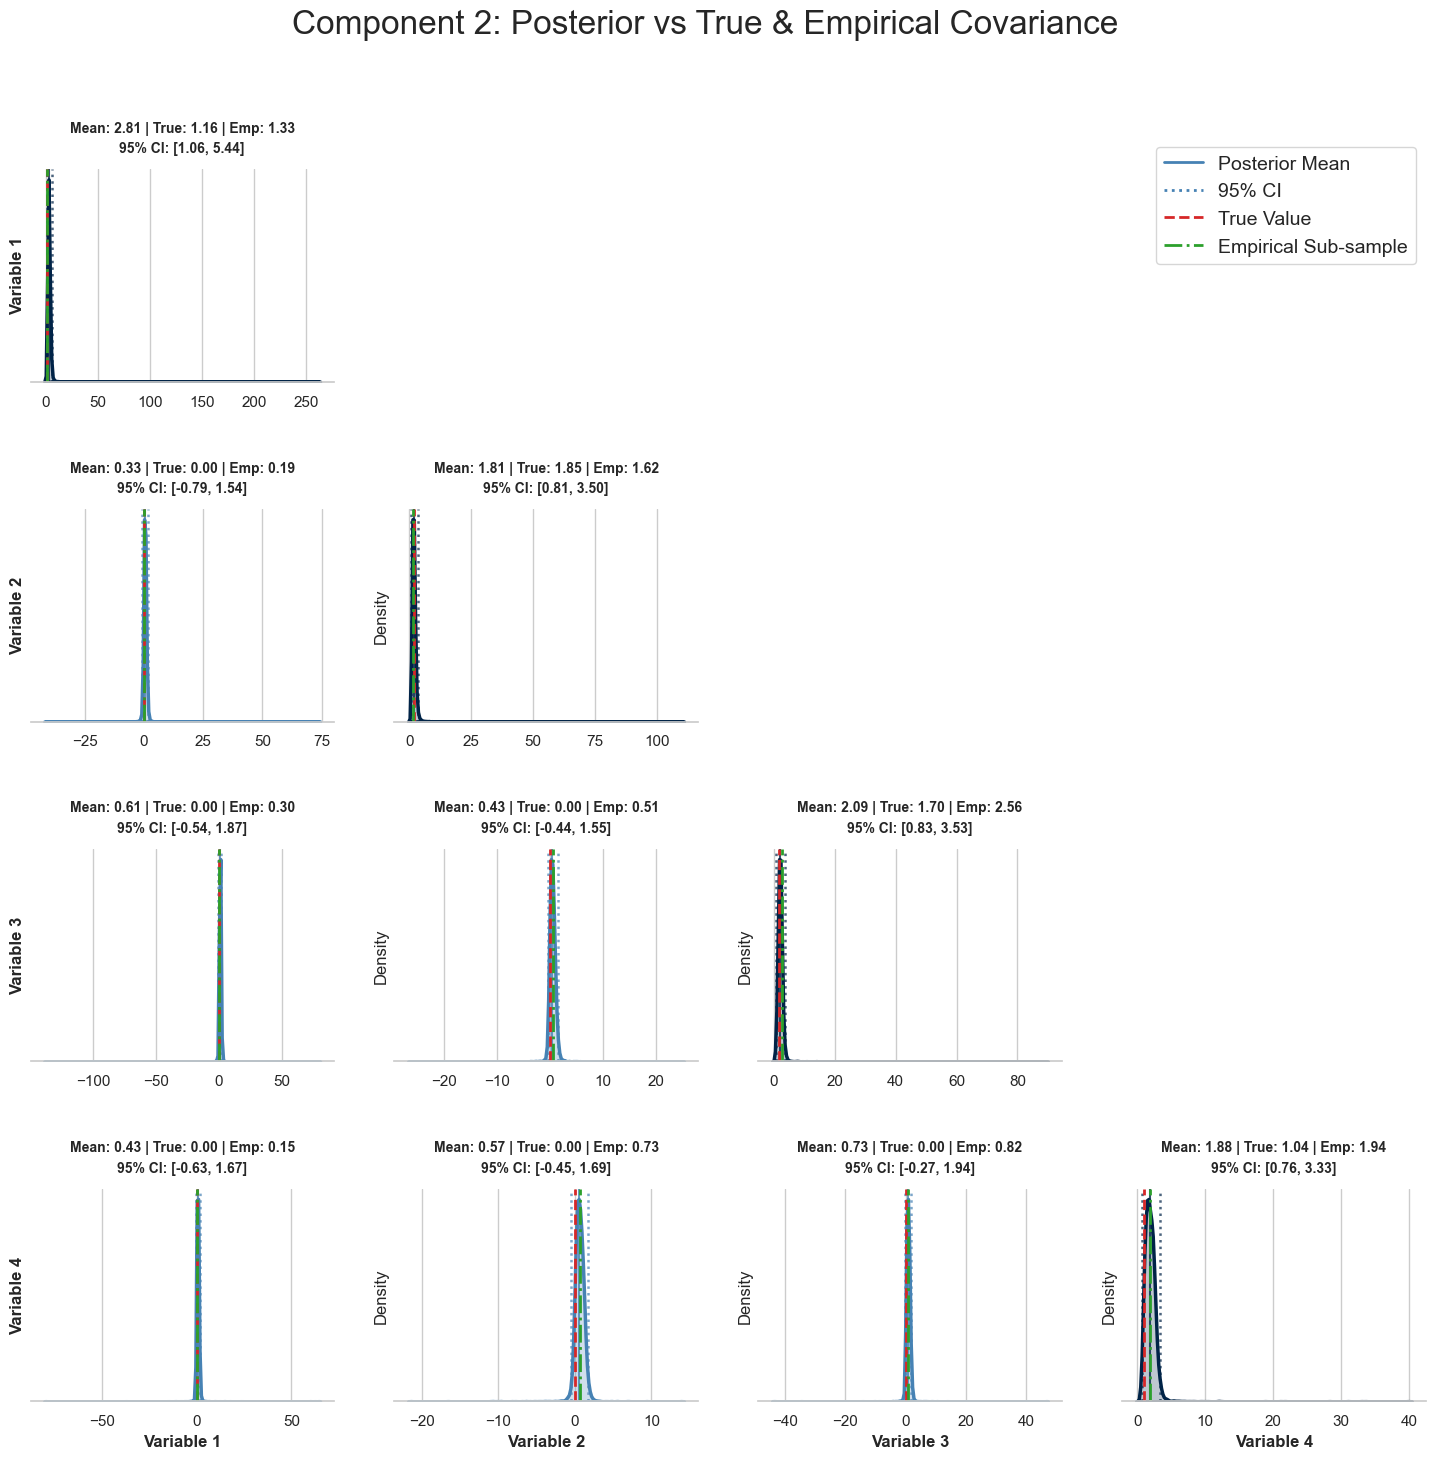

In [17]:
# ── MCMC diagnostics ───────────────────────────────────────────────────────────

print("\n=== MCMC Convergence Summary ===")
summary = gs.Summary(mcmc_results)


def plot_cholesky_traces(samples_dict, n_params, k_idx=0,
                         param_name="sigma_inv_chol_k_latent", figsize=(15, 12)):
    latent_samples = samples_dict[param_name][:, :, k_idx, :]
    n_chains, n_draws, n_latent = latent_samples.shape

    fig, axes = plt.subplots(n_params, n_params, figsize=figsize, sharex=True, sharey=False)
    if n_params == 1:
        axes = np.array([[axes]])

    latent_idx = 0
    for i in range(n_params):
        for j in range(n_params):
            ax = axes[i, j]
            if i >= j and latent_idx < n_latent:
                for chain in range(n_chains):
                    ax.plot(latent_samples[chain, :, latent_idx], label=f"Chain {chain}")
                ax.set_title(f"Latent L[{i},{j}]", fontsize=10)
                latent_idx += 1
            else:
                ax.axis('off')

            ax.grid(True)
            if j == 0:
                ax.set_ylabel("Value")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=n_chains,
               bbox_to_anchor=(0.5, 0.02))
    plt.suptitle(
        f"MCMC Trace: {param_name} (Component {k_idx}) - {n_params}x{n_params}",
        fontsize=20
    )
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


for k in range(K):
    plot_cholesky_traces(posterior_samples_sorted, n_params=P, k_idx=k)


# ── Covariance recovery ────────────────────────────────────────────────────────

print("\nRecovering Covariance Matrices (Sigma_k) from sorted samples...")

bijector_tril = tfb.FillScaleTriL()


def latent_to_sigma(latent_vec):
    """FillScaleTriL latent vector -> Sigma (covariance matrix)."""
    L         = bijector_tril.forward(latent_vec)
    precision = L @ L.T
    return jnp.linalg.inv(precision)


v_latent_to_sigma = jax.vmap(jax.vmap(jax.vmap(latent_to_sigma)))
latent_samples_sorted = posterior_samples_sorted["sigma_inv_chol_k_latent"]
sigma_samples_sorted  = v_latent_to_sigma(latent_samples_sorted)  # (chains, draws, K, P, P)


def plot_final_covariance_complete(samples, true_matrix=None, empirical_matrix=None,
                                   component_idx=0):
    n_dim             = samples.shape[-1]
    fig, axes         = plt.subplots(n_dim, n_dim, figsize=(18, 16))
    flattened_samples = samples.reshape(-1, n_dim, n_dim)

    diag_color     = "#002347"
    off_diag_color = "#4682B4"
    true_val_color = "#D62728"
    emp_val_color  = "#2CA02C"

    for i in range(n_dim):
        for j in range(n_dim):
            ax = axes[i, j]
            if j > i:
                ax.axis('off')
                continue

            data_vec      = flattened_samples[:, i, j]
            current_color = diag_color if (i == j) else off_diag_color
            post_mean     = np.mean(data_vec)
            ci_low, ci_high = np.percentile(data_vec, [2.5, 97.5])

            sns.kdeplot(data_vec, ax=ax, fill=True, color=current_color, alpha=0.25, lw=2.5)
            ax.axvline(post_mean, color=current_color, linestyle="-",  lw=1.5, alpha=0.8)
            ax.axvline(ci_low,    color=current_color, linestyle=":",  lw=1.8, alpha=0.7)
            ax.axvline(ci_high,   color=current_color, linestyle=":",  lw=1.8, alpha=0.7)

            title_parts = [f"Mean: {post_mean:.2f}"]
            if true_matrix is not None:
                ax.axvline(true_matrix[i, j], color=true_val_color, linestyle="--", lw=2)
                title_parts.append(f"True: {true_matrix[i, j]:.2f}")
            if empirical_matrix is not None:
                ax.axvline(empirical_matrix[i, j], color=emp_val_color, linestyle="-.", lw=2)
                title_parts.append(f"Emp: {empirical_matrix[i, j]:.2f}")

            title_str = f"{' | '.join(title_parts)}\n95% CI: [{ci_low:.2f}, {ci_high:.2f}]"
            ax.set_title(title_str, fontsize=10, pad=12, linespacing=1.6, fontweight='bold')
            ax.set_yticks([])
            sns.despine(ax=ax, left=True)

            if i == n_dim - 1:
                ax.set_xlabel(f"Variable {j + 1}", fontsize=12, fontweight='bold')
            if j == 0:
                ax.set_ylabel(f"Variable {i + 1}", fontsize=12, fontweight='bold')

    legend_elements = [
        Line2D([0], [0], color=off_diag_color, linestyle='-',  lw=2, label='Posterior Mean'),
        Line2D([0], [0], color=off_diag_color, linestyle=':',  lw=2, label='95% CI'),
        Line2D([0], [0], color=true_val_color, linestyle='--', lw=2, label='True Value'),
        Line2D([0], [0], color=emp_val_color,  linestyle='-.', lw=2, label='Empirical Sub-sample')
    ]
    fig.legend(handles=legend_elements, loc='upper right',
               bbox_to_anchor=(0.9, 0.9), fontsize=14, frameon=True)
    plt.suptitle(
        f"Component {component_idx}: Posterior vs True & Empirical Covariance",
        fontsize=24, y=0.98
    )
    plt.subplots_adjust(hspace=0.6, wspace=0.2)
    plt.show()


for k in range(K):
    comp_mask         = choice_data["TRUE_INDICATORS"] == k
    comp_betas        = choice_data["TRUE_BETA"][comp_mask]
    empirical_sigma_k = jnp.cov(comp_betas, rowvar=False) if len(comp_betas) > 1 else None
    plot_final_covariance_complete(
        samples=sigma_samples_sorted[:, :, k, :, :],
        true_matrix=choice_data["TRUE_SIGMA_K"][k],
        empirical_matrix=empirical_sigma_k,
        component_idx=k
    )


=== Detailed Delta Parameter Diagnostics (Goose Style) ===


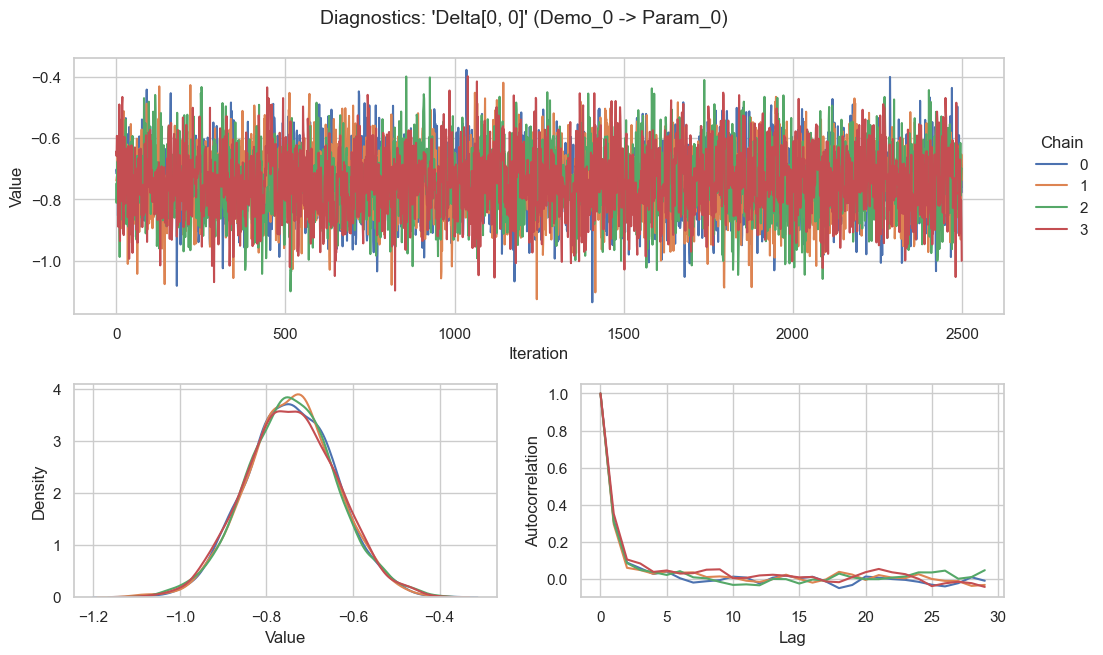

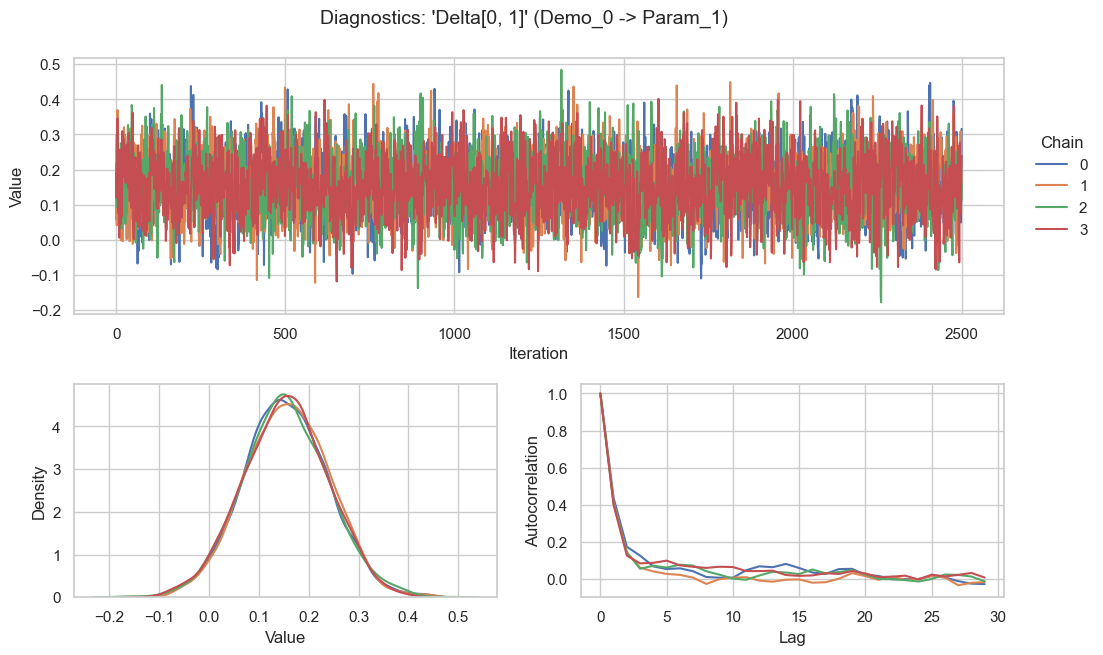

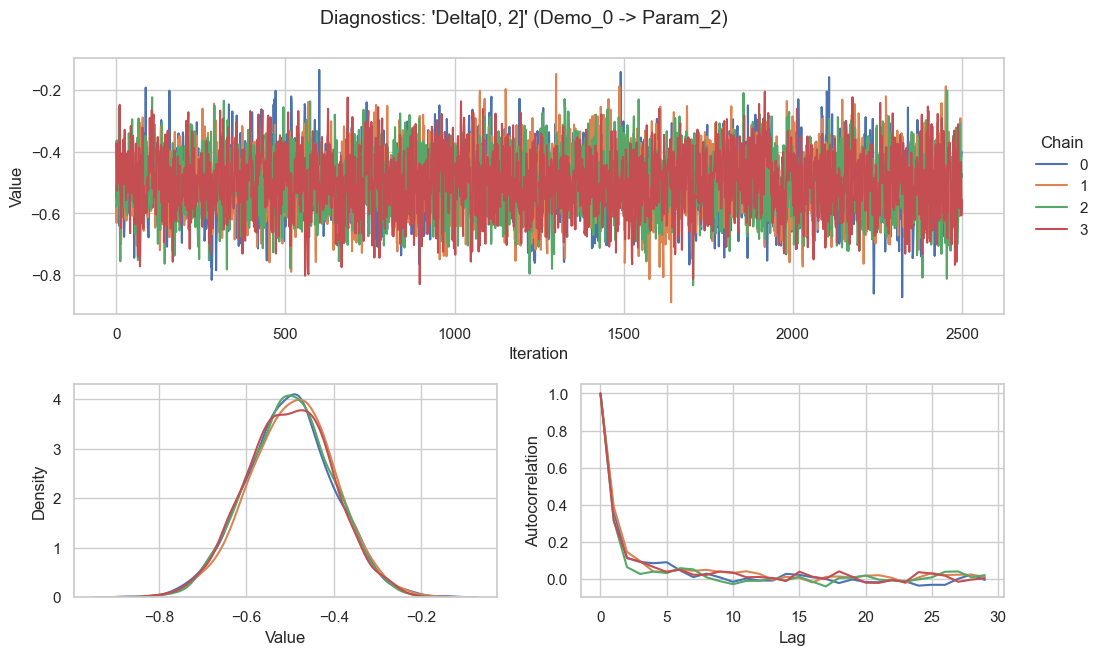

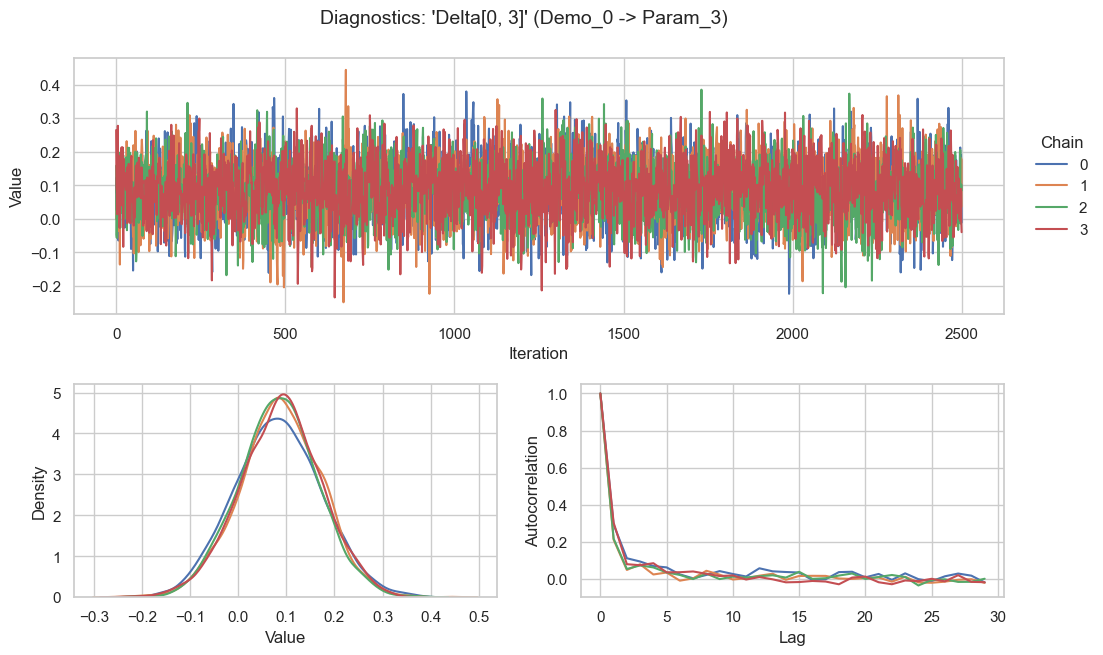

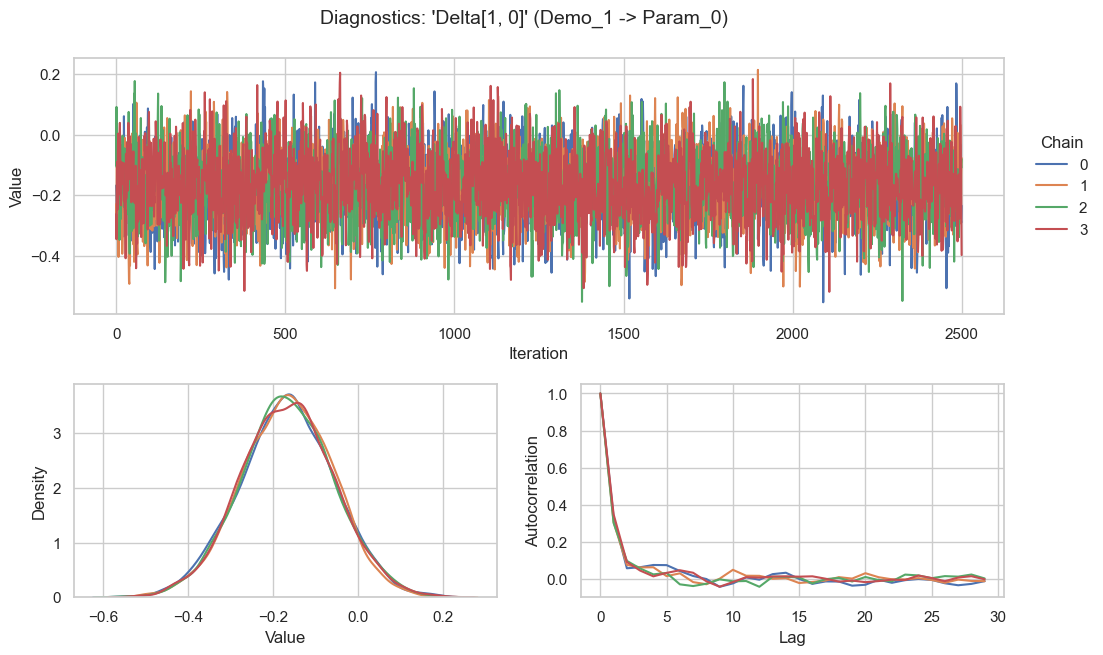

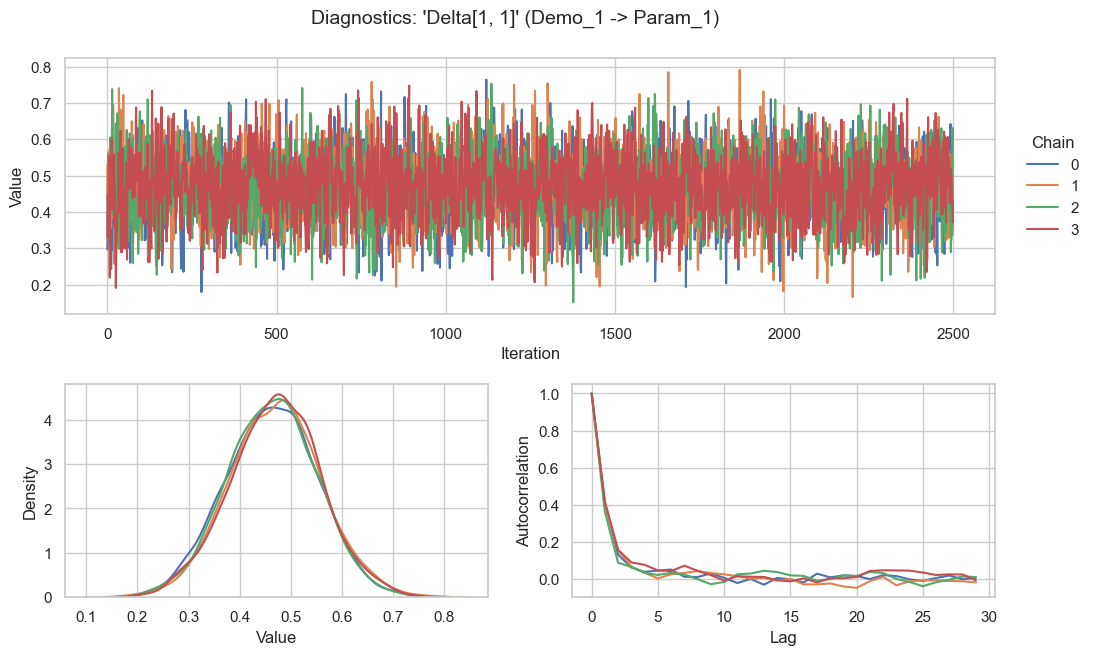

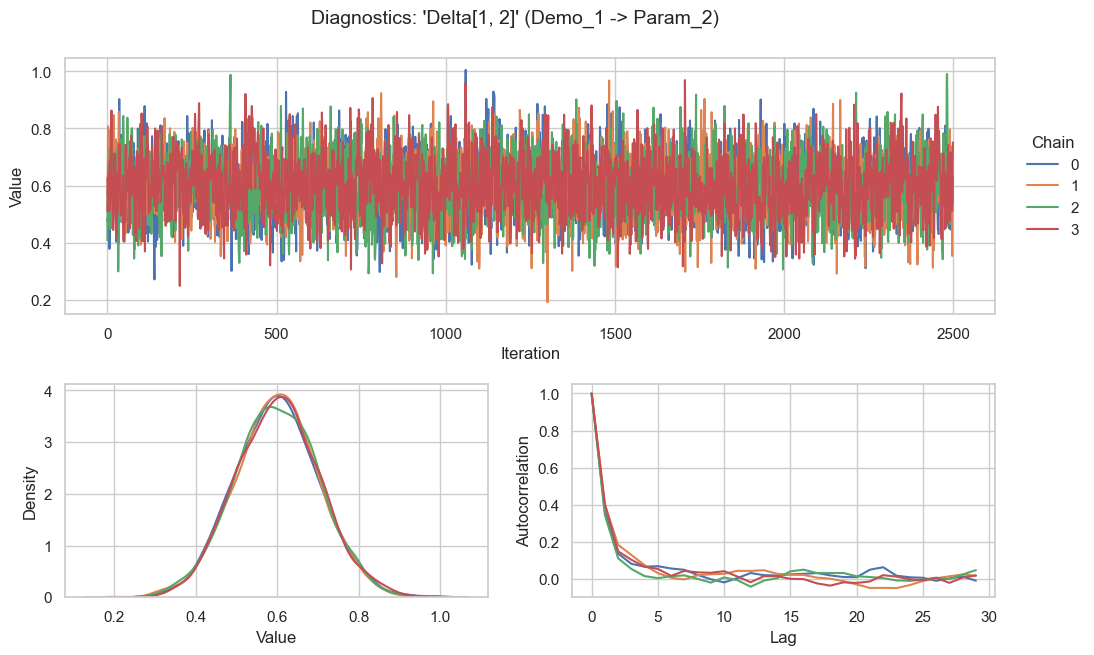

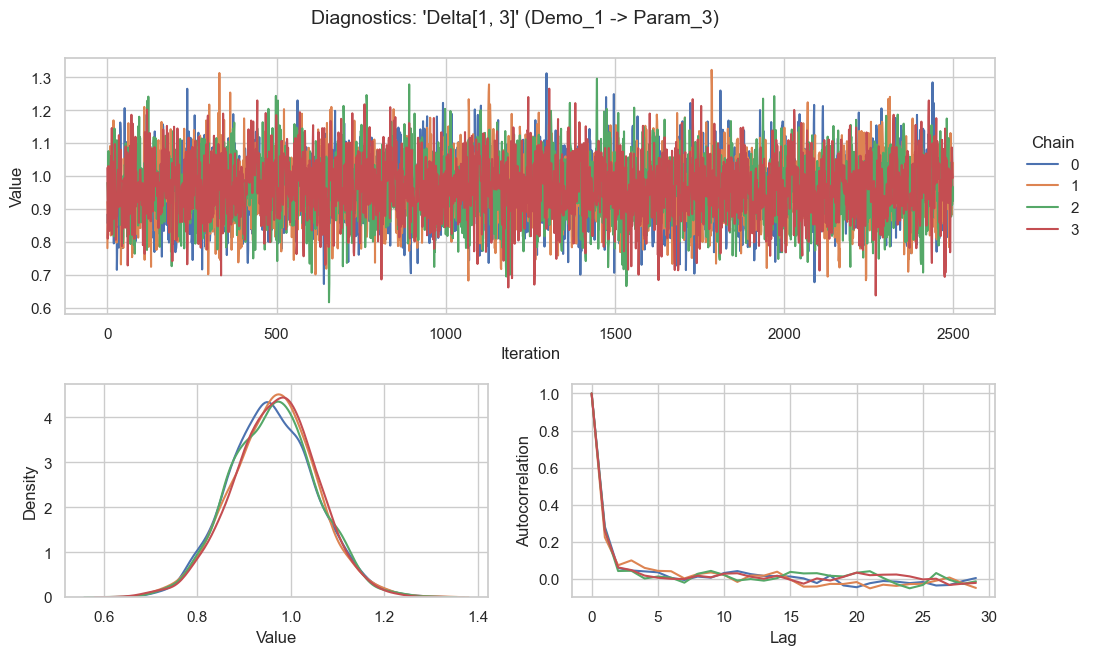

In [18]:
# ── Goose-style chain diagnostics ──────────────────────────────────────────────

def compute_acf(x, nlags=30):
    x_centered = x - np.mean(x)
    norm       = np.sum(x_centered ** 2)
    if norm == 0:
        return np.zeros(nlags)
    acf = np.correlate(x_centered, x_centered, mode='full')
    return (acf[acf.size // 2:] / norm)[:nlags]


def plot_goose_style_diagnostics(delta_array, demo_idx, param_idx,
                                 demo_name, param_name, n_lags=30):
    n_chains = delta_array.shape[0]
    fig = plt.figure(figsize=(12, 7))
    fig.suptitle(
        f"Diagnostics: 'Delta[{demo_idx}, {param_idx}]' ({demo_name} -> {param_name})",
        fontsize=14, y=0.95
    )
    gs_layout = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1], hspace=0.3, wspace=0.2)

    ax_trace = fig.add_subplot(gs_layout[0, :])
    for chain in range(n_chains):
        ax_trace.plot(delta_array[chain, :, demo_idx, param_idx], label=f"{chain}")
    ax_trace.set_xlabel("Iteration")
    ax_trace.set_ylabel("Value")
    ax_trace.grid(True, alpha=1)
    ax_trace.legend(title="Chain", loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

    ax_dens = fig.add_subplot(gs_layout[1, 0])
    for chain in range(n_chains):
        sns.kdeplot(delta_array[chain, :, demo_idx, param_idx], ax=ax_dens, fill=False)
    ax_dens.set_xlabel("Value")
    ax_dens.set_ylabel("Density")
    ax_dens.grid(True)

    ax_acf = fig.add_subplot(gs_layout[1, 1])
    for chain in range(n_chains):
        ax_acf.plot(
            compute_acf(delta_array[chain, :, demo_idx, param_idx], nlags=n_lags), alpha=1
        )
    ax_acf.set_xlabel("Lag")
    ax_acf.set_ylabel("Autocorrelation")
    ax_acf.set_ylim(-0.1, 1.05)
    ax_acf.grid(True)
    plt.show()


print("\n=== Detailed Delta Parameter Diagnostics (Goose Style) ===")
raw_delta_samples = posterior_samples_sorted["Delta"]
for i in range(D):
    for j in range(P):
        plot_goose_style_diagnostics(
            raw_delta_samples, demo_idx=i, param_idx=j,
            demo_name=f"Demo_{i}", param_name=f"Param_{j}"
        )


=== Global Parameters (Baseline Means mu_k) Summary Tables ===

--- Sorted MCMC Component 0 (Mapped to True Component 2) ---


,True_Value,Posterior_Mean,Diff_Abs,Posterior_Std
Parameter,,,,
Param_0,0.5,0.6801,0.1801,0.9384
Param_1,0.5,-0.0367,0.5367,1.4359
Param_2,1.0,0.3955,0.6045,0.9538
Param_3,-0.1,-0.6789,0.5789,1.0781



--- Sorted MCMC Component 1 (Mapped to True Component 0) ---


,True_Value,Posterior_Mean,Diff_Abs,Posterior_Std
Parameter,,,,
Param_0,2.0,1.8602,0.1398,0.9338
Param_1,-1.0,-0.6884,0.3116,0.5857
Param_2,-1.0,-1.3146,0.3146,1.1526
Param_3,-0.5,-0.5512,0.0512,0.7714



--- Sorted MCMC Component 2 (Mapped to True Component 1) ---


...


=== Posterior distribution of Delta (mean + std) ===


,Param_0,Param_1,Param_2,Param_3
Demo_0,-0.74 (0.10),0.15 (0.09),-0.50 (0.10),0.09 (0.09)
Demo_1,-0.17 (0.11),0.47 (0.09),0.60 (0.10),0.96 (0.09)



=== Absolute Difference in Delta (|True - Posterior|) ===


,Param_0,Param_1,Param_2,Param_3
Demo_0,0.162,0.015,0.051,0.131
Demo_1,0.026,0.041,0.142,0.096



Plotting Delta Distributions...


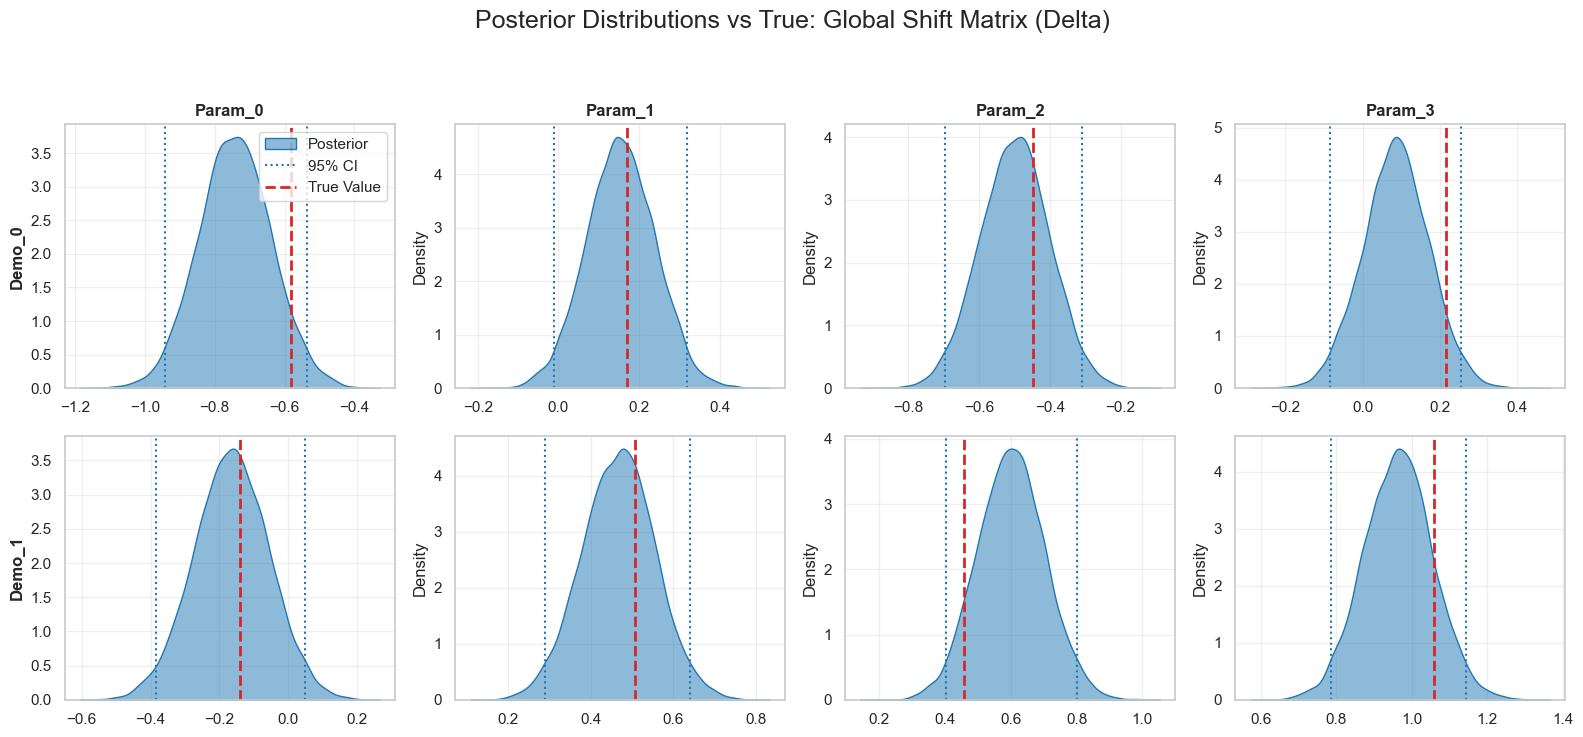

In [20]:
# ── Global parameters: baseline means & Delta ─────────────────────────────────

def create_summary_table(t_mu, post_mu, p_names):
    return pd.DataFrame({
        'Parameter':      p_names,
        'True_Value':     t_mu,
        'Posterior_Mean': post_mu.mean(axis=0),
        'Diff_Abs':       np.abs(t_mu - post_mu.mean(axis=0)),
        'Posterior_Std':  post_mu.std(axis=0)
    }).round(4).set_index("Parameter")


print("\n=== Global Parameters (Baseline Means mu_k) Summary Tables ===")
mu_samples_sorted      = posterior_samples_sorted["mu_k"]
mu_samples_sorted_flat = mu_samples_sorted.reshape(-1, K, P)

# Map sorted MCMC components to true component indices via Hungarian algorithm
sorted_mu_mean = mu_samples_sorted_flat.mean(axis=0)  # (K, P)
cost_matrix    = np.sum(
    (sorted_mu_mean[:, None, :] - choice_data["TRUE_MU_K"][None, :, :]) ** 2,
    axis=-1
)
_, true_mapping = linear_sum_assignment(cost_matrix)

for k in range(K):
    true_k = true_mapping[k]
    print(f"\n--- Sorted MCMC Component {k} (Mapped to True Component {true_k}) ---")
    display(create_summary_table(
        t_mu=choice_data["TRUE_MU_K"][true_k],
        post_mu=mu_samples_sorted_flat[:, k, :],
        p_names=param_names
    ))


def generate_delta_table(delta_draws, p_names, d_names):
    mean = np.mean(delta_draws, axis=0)
    std  = np.std(delta_draws,  axis=0)
    df   = pd.DataFrame(index=d_names, columns=p_names)
    for i in range(len(d_names)):
        for j in range(len(p_names)):
            df.iloc[i, j] = f"{mean[i, j]:.2f} ({std[i, j]:.2f})"
    return df


def generate_delta_diff_table(t_delta, l_delta, p_names, d_names):
    diff_mean = np.abs(t_delta - np.mean(l_delta, axis=0))
    df        = pd.DataFrame(index=d_names, columns=p_names)
    for i in range(len(d_names)):
        for j in range(len(p_names)):
            df.iloc[i, j] = f"{diff_mean[i, j]:.3f}"
    return df


print("\n=== True distribution of Delta (Ground Truth) ===")
display(pd.DataFrame(choice_data["TRUE_DELTA"], index=demo_names, columns=param_names))

delta_samples_sorted = posterior_samples_sorted["Delta"].reshape(-1, D, P)

print("\n=== Posterior distribution of Delta (mean + std) ===")
display(generate_delta_table(delta_samples_sorted, param_names, demo_names))

print("\n=== Absolute Difference in Delta (|True - Posterior|) ===")
display(generate_delta_diff_table(
    choice_data["TRUE_DELTA"], delta_samples_sorted, param_names, demo_names
))


def plot_delta_distributions(delta_samples, t_delta, p_names, d_names):
    n_demos, n_params = len(d_names), len(p_names)
    fig, axes = plt.subplots(n_demos, n_params, figsize=(4 * n_params, 3.5 * n_demos))

    for d in range(n_demos):
        for p in range(n_params):
            ax      = axes[d, p] if n_demos > 1 else axes[p]
            samples = delta_samples[:, d, p]
            t_val   = t_delta[d, p]
            ci_low, ci_high = np.percentile(samples, [2.5, 97.5])

            sns.kdeplot(samples, ax=ax, fill=True, color="#1f77b4", alpha=0.5, label="Posterior")
            ax.axvline(ci_low,  color="#1f77b4", linestyle=":", lw=1.5, label="95% CI")
            ax.axvline(ci_high, color="#1f77b4", linestyle=":", lw=1.5)
            ax.axvline(t_val,   color="#D62728", linestyle="--", lw=2, label="True Value")

            if d == 0:
                ax.set_title(p_names[p], fontweight='bold')
            if p == 0:
                ax.set_ylabel(d_names[d], fontweight='bold')
            ax.grid(True, alpha=0.3)

            if d == 0 and p == 0:
                handles, labels = ax.get_legend_handles_labels()
                unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
                ax.legend(*zip(*unique), loc='upper right')

    plt.suptitle("Posterior Distributions vs True: Global Shift Matrix (Delta)",
                 fontsize=18, y=1.05)
    plt.tight_layout()
    plt.show()


print("\nPlotting Delta Distributions...")
plot_delta_distributions(delta_samples_sorted, choice_data["TRUE_DELTA"], param_names, demo_names)

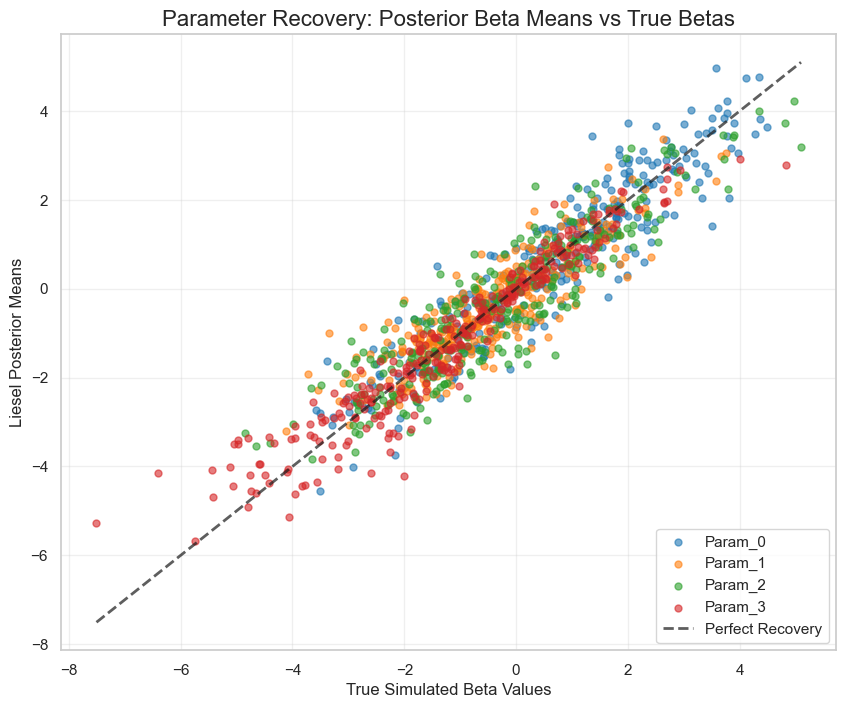


Plotting Household-Level Distributions...


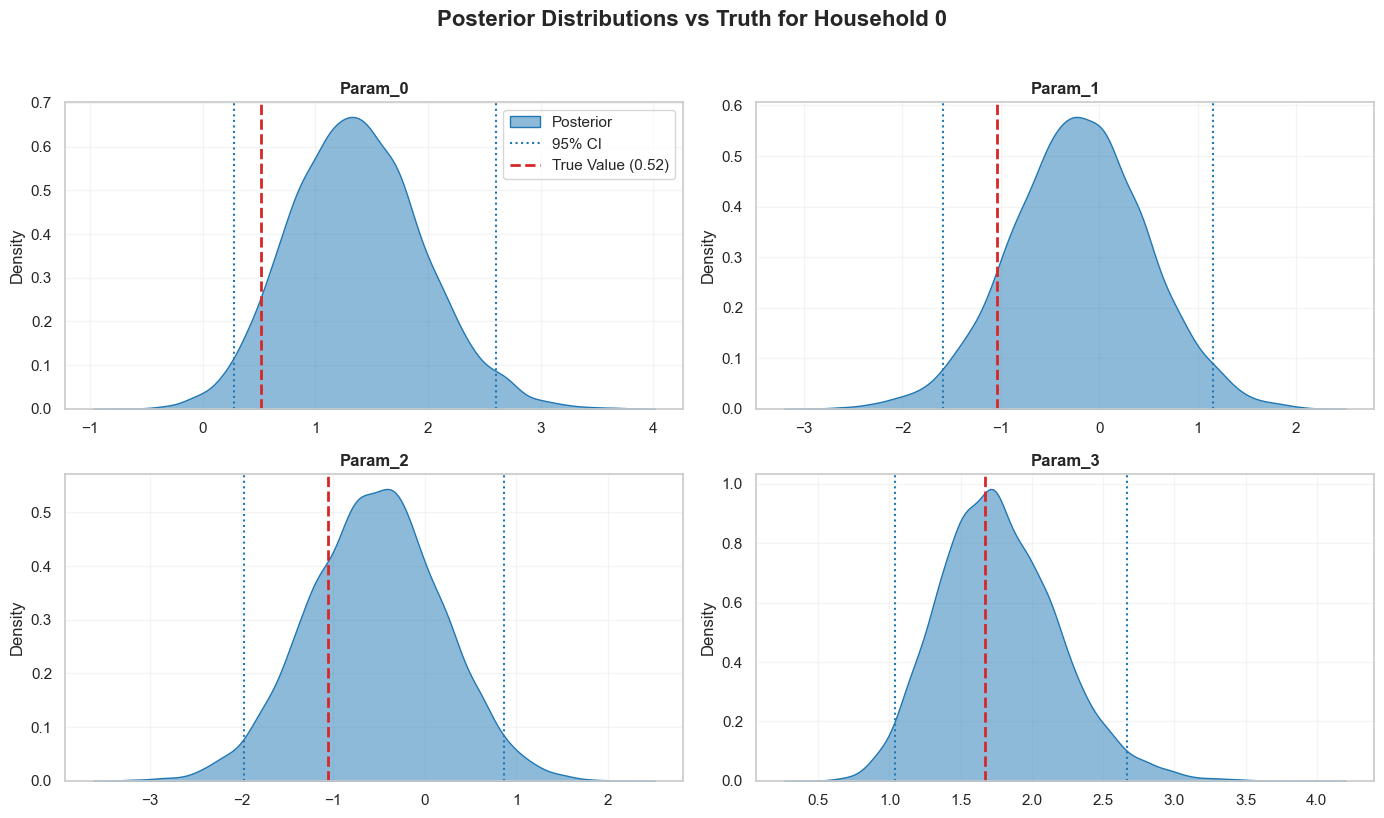

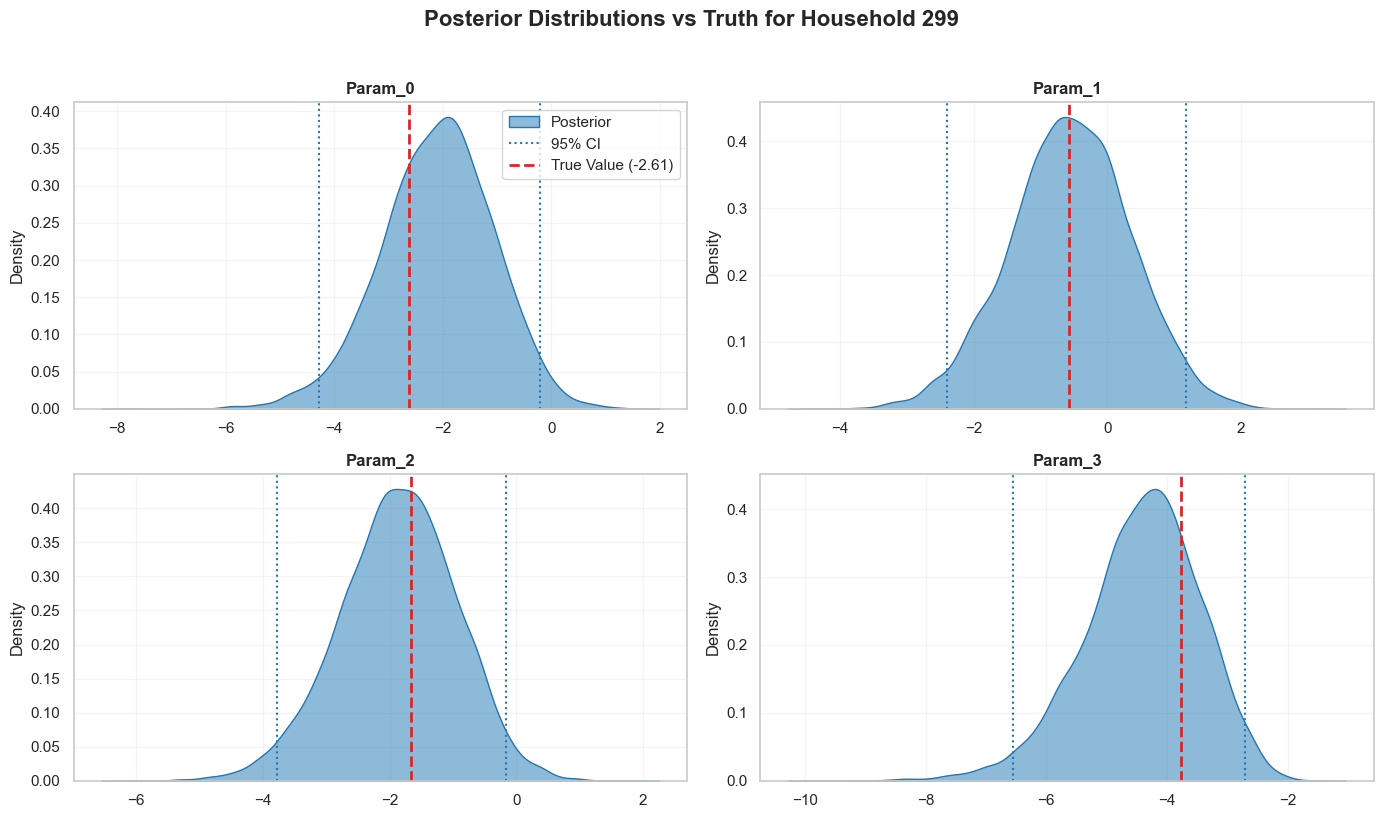

In [19]:
# ── Household heterogeneity (betas) ───────────────────────────────────────────

n_chains_b, n_draws_b, n_units_b, n_params_b = posterior_samples_sorted["beta_i"].shape
liesel_beta_full = posterior_samples_sorted["beta_i"].reshape(-1, n_units_b, n_params_b)
true_betas_full  = choice_data["TRUE_BETA"]
l_beta_means     = np.mean(liesel_beta_full, axis=0)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
colors  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'][:P]
for i, param in enumerate(param_names):
    ax.scatter(true_betas_full[:, i], l_beta_means[:, i],
               alpha=0.6, s=25, label=param, color=colors[i])

min_val = min(true_betas_full.min(), l_beta_means.min())
max_val = max(true_betas_full.max(), l_beta_means.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, alpha=0.7, label='Perfect Recovery')
ax.set_title("Parameter Recovery: Posterior Beta Means vs True Betas", fontsize=16)
ax.set_xlabel("True Simulated Beta Values", fontsize=12)
ax.set_ylabel("Liesel Posterior Means", fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.show()


def plot_beta_distributions(samples, true_vals, p_names, title_prefix,
                             color_l="#1f77b4", color_t="#d62728"):
    cols = 2
    rows = int(np.ceil(len(p_names) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
    if len(p_names) == 1:
        axes = np.array([axes])

    for i, (ax, param) in enumerate(zip(axes.flatten(), p_names)):
        if i >= len(p_names):
            ax.axis('off')
            continue

        l_vals  = samples[:, i]
        t_val   = true_vals[i]
        ci_low, ci_high = np.percentile(l_vals, [2.5, 97.5])

        sns.kdeplot(l_vals, ax=ax, fill=True, color=color_l, alpha=0.5, label="Posterior")
        ax.axvline(ci_low,  color=color_l, linestyle=":", lw=1.5, label="95% CI")
        ax.axvline(ci_high, color=color_l, linestyle=":", lw=1.5)
        ax.axvline(t_val,   color=color_t, linestyle="--", lw=2,
                   label=f"True Value ({t_val:.2f})")

        ax.set_title(param, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.2)

        if i == 0:
            handles, labels = ax.get_legend_handles_labels()
            unique = [(h, l) for j2, (h, l) in enumerate(zip(handles, labels))
                      if l not in labels[:j2]]
            ax.legend(*zip(*unique), loc="upper right")

    plt.suptitle(title_prefix, y=1.02, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


print("\nPlotting Household-Level Distributions...")
plot_beta_distributions(
    liesel_beta_full[:, 0, :], true_betas_full[0, :], param_names,
    "Posterior Distributions vs Truth for Household 0"
)
plot_beta_distributions(
    liesel_beta_full[:, -1, :], true_betas_full[-1, :], param_names,
    f"Posterior Distributions vs Truth for Household {n_units_b - 1}"
)

Posterior mean pvec: [0.30487558 0.3414695  0.35365424]
True pvec:           [0.4  0.35 0.25]

=== pvec: Posterior Summary ===


,True_pvec,Posterior_Mean,Posterior_Std,CI_2.5%,CI_97.5%,True_in_CI
Component,,,,,,
0,0.40,0.3049,0.1140,0.1100,0.5575,True
1,0.35,0.3415,0.1028,0.1480,0.5744,True
2,0.25,0.3537,0.1250,0.0794,0.5845,True



=== pvec: Goose-Style Chain Diagnostics ===


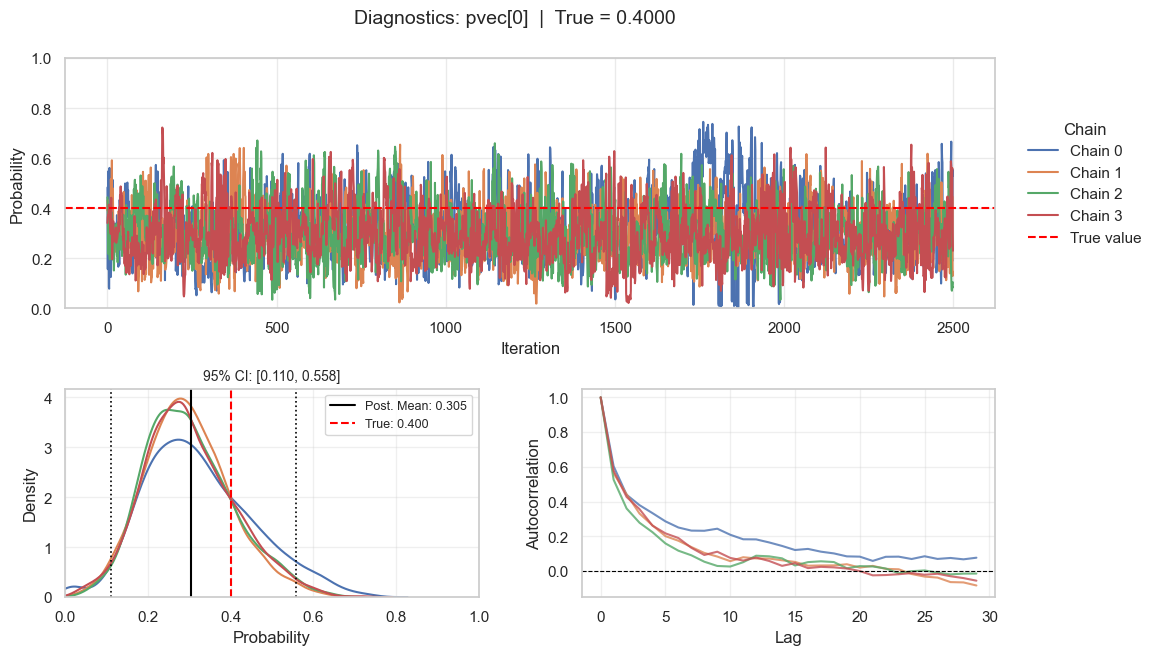

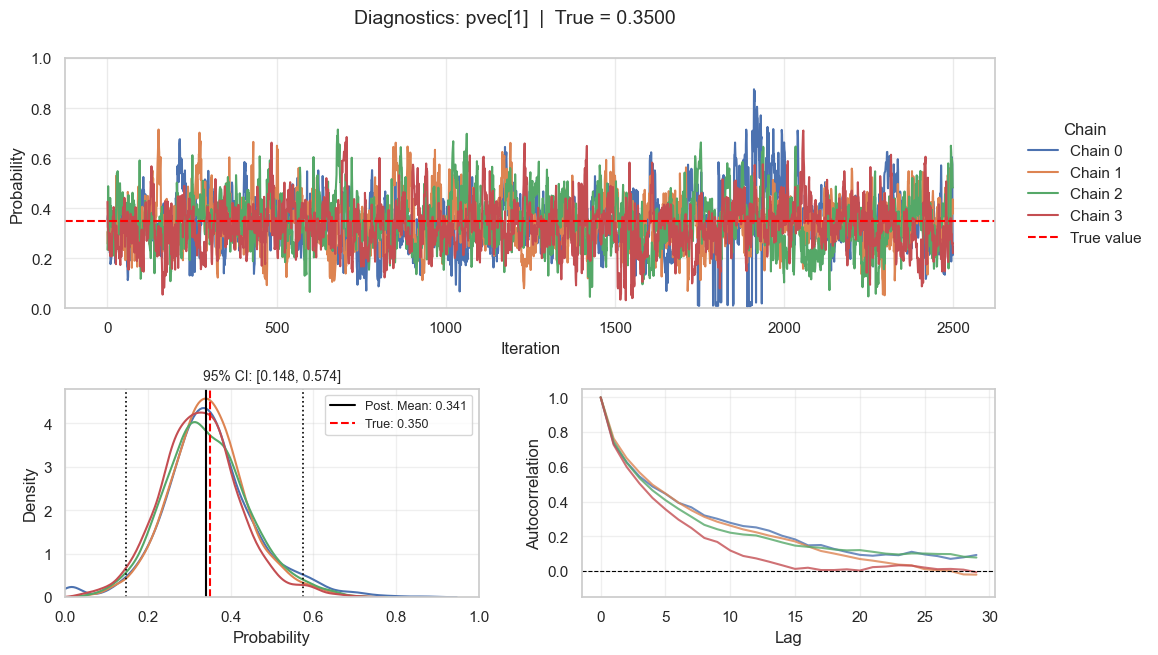

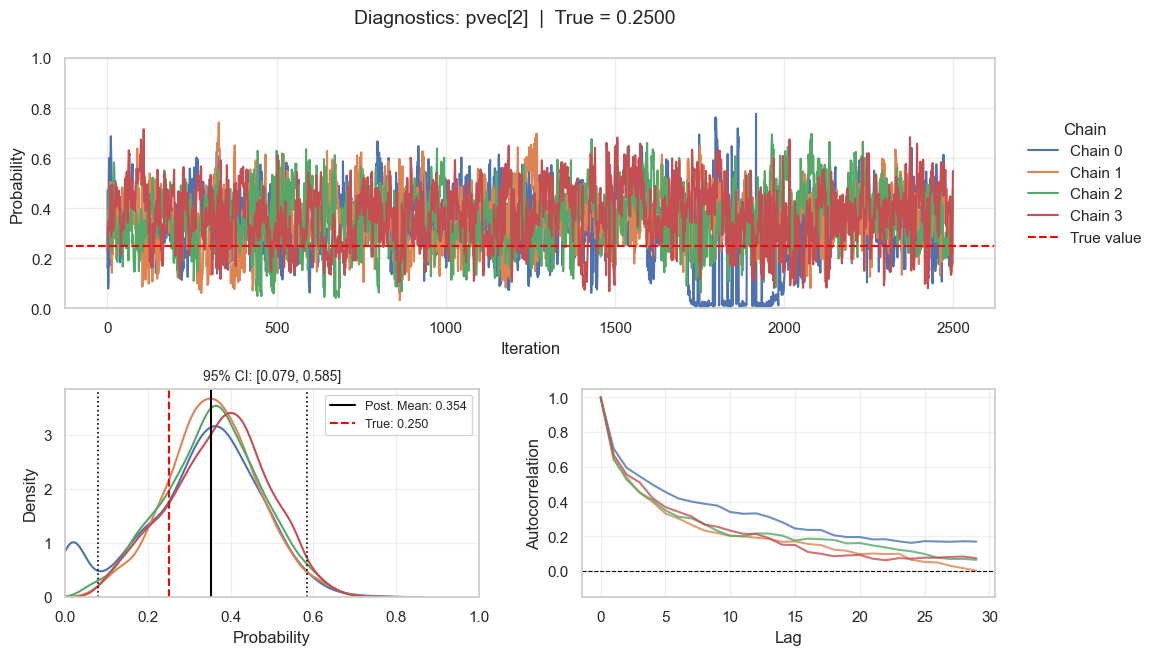

In [21]:
# ── pvec diagnostics & posterior summary ──────────────────────────────────────

flat_pvec = posterior_samples_sorted["pvec"].reshape(-1, K)
print("Posterior mean pvec:", flat_pvec.mean(axis=0))
# FIXED: Changed sim_data to choice_data
print("True pvec:          ", choice_data["TRUE_PVEC"])


def plot_pvec_diagnostics(pvec_samples_sorted, true_pvec, K, n_lags=30):
    """Goose-style trace / density / ACF for each mixture weight."""
    n_chains, n_draws, _ = pvec_samples_sorted.shape

    for k in range(K):
        fig = plt.figure(figsize=(12, 7))
        fig.suptitle(f"Diagnostics: pvec[{k}]  |  True = {true_pvec[k]:.4f}",
                     fontsize=14, y=0.95)
        gs_layout = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1],
                                      hspace=0.35, wspace=0.25)

        ax_trace = fig.add_subplot(gs_layout[0, :])
        for chain in range(n_chains):
            ax_trace.plot(pvec_samples_sorted[chain, :, k], label=f"Chain {chain}")
        ax_trace.axhline(true_pvec[k], color="red", linestyle="--",
                         lw=1.5, label="True value")
        ax_trace.set_xlabel("Iteration")
        ax_trace.set_ylabel("Probability")
        ax_trace.set_ylim(0, 1)
        ax_trace.grid(True, alpha=0.4)
        ax_trace.legend(title="Chain", loc='center left',
                        bbox_to_anchor=(1.02, 0.5), frameon=False)

        ax_dens = fig.add_subplot(gs_layout[1, 0])
        all_draws = pvec_samples_sorted[:, :, k].reshape(-1)
        post_mean = all_draws.mean()
        ci_low, ci_high = np.percentile(all_draws, [2.5, 97.5])

        for chain in range(n_chains):
            sns.kdeplot(pvec_samples_sorted[chain, :, k], ax=ax_dens, fill=False)
        ax_dens.axvline(post_mean,    color="black", linestyle="-",  lw=1.5,
                        label=f"Post. Mean: {post_mean:.3f}")
        ax_dens.axvline(ci_low,       color="black", linestyle=":",  lw=1.2)
        ax_dens.axvline(ci_high,      color="black", linestyle=":",  lw=1.2)
        ax_dens.axvline(true_pvec[k], color="red",   linestyle="--", lw=1.5,
                        label=f"True: {true_pvec[k]:.3f}")
        ax_dens.set_xlabel("Probability")
        ax_dens.set_ylabel("Density")
        ax_dens.set_xlim(0, 1)
        ax_dens.legend(fontsize=9)
        ax_dens.grid(True, alpha=0.3)
        ax_dens.set_title(f"95% CI: [{ci_low:.3f}, {ci_high:.3f}]", fontsize=10)

        ax_acf = fig.add_subplot(gs_layout[1, 1])
        for chain in range(n_chains):
            ax_acf.plot(
                compute_acf(pvec_samples_sorted[chain, :, k], nlags=n_lags),
                alpha=0.8, label=f"Chain {chain}"
            )
        ax_acf.axhline(0, color="black", lw=0.8, linestyle="--")
        ax_acf.set_xlabel("Lag")
        ax_acf.set_ylabel("Autocorrelation")
        ax_acf.set_ylim(-0.15, 1.05)
        ax_acf.grid(True, alpha=0.3)

        plt.show()


def pvec_summary_table(pvec_samples_sorted, true_pvec, K):
    flat = pvec_samples_sorted.reshape(-1, K)
    rows = []
    for k in range(K):
        draws = flat[:, k]
        ci_low, ci_high = np.percentile(draws, [2.5, 97.5])
        rows.append({
            "Component":      k,
            "True_pvec":      true_pvec[k],
            "Posterior_Mean": draws.mean(),
            "Posterior_Std":  draws.std(),
            "CI_2.5%":        ci_low,
            "CI_97.5%":       ci_high,
            "True_in_CI":     ci_low <= true_pvec[k] <= ci_high
        })
    return pd.DataFrame(rows).set_index("Component").round(4)


print("\n=== pvec: Posterior Summary ===")
# FIXED: Changed sim_data to choice_data
display(pvec_summary_table(
    posterior_samples_sorted["pvec"], choice_data["TRUE_PVEC"], K
))

print("\n=== pvec: Goose-Style Chain Diagnostics ===")
# FIXED: Changed sim_data to choice_data
plot_pvec_diagnostics(
    posterior_samples_sorted["pvec"], choice_data["TRUE_PVEC"], K
)

In [22]:
# ── Cell 5b : Export Liesel Posterior for Marginal Density Comparison ─────────
#
# This cell must run AFTER Cell 5 (label switching / PRA resolution).
# It fixes the three undefined-variable bugs in the original export snippet
# and saves a .pkl that is 100 % compatible with the comparison plotting
# script (compare_marginals.py).
#
# Saved keys
# ----------
#   mu   : (R, K, P)       — component means
#   std  : (R, K, P)       — marginal standard deviations (sqrt of cov diagonal)
#   pvec : (R, K)          — mixture probabilities
# where R = n_chains × n_draws (chains and draws collapsed together).
# ==============================================================================

import pickle
import pathlib
import numpy as np
import tensorflow_probability.substrates.jax.bijectors as tfb

# ── Helper ─────────────────────────────────────────────────────────────────────
# ── Helper ─────────────────────────────────────────────────────────────────────
def save_draws_to_pickle(filename, mu_draws, cov_draws, pvec_draws=None):
    """
    Extracts marginal standard deviations and saves mu, std, sigma, pvec to .pkl.

    Parameters
    ----------
    filename   : str — file name inside the 'Data/' directory
    mu_draws   : (R, K, nvar)    — component means
    cov_draws  : (R, K, nvar, nvar) — full covariance matrices
    pvec_draws : (R, K) or None  — mixture weights; defaults to 1 if K=1
    """
    R, K, nvar = mu_draws.shape

    # Marginal standard deviations from the diagonal of Sigma_k
    std_draws = np.zeros((R, K, nvar))
    for k in range(K):
        for j in range(nvar):
            std_draws[:, k, j] = np.sqrt(np.maximum(cov_draws[:, k, j, j], 0.0))

    if pvec_draws is None:
        pvec_draws = np.ones((R, K))

    # ADD 'sigma' HERE:
    data_dict = {
        "mu": mu_draws, 
        "std": std_draws, 
        "pvec": pvec_draws,
        "sigma": cov_draws  # <--- This fixes the KeyError
    }

    filepath = pathlib.Path("Data") / filename
    filepath.parent.mkdir(parents=True, exist_ok=True)
    with open(filepath, "wb") as f:
        pickle.dump(data_dict, f)

    print(f"Saved {K}-component draws → {filepath}")
    print(f"  mu    shape : {mu_draws.shape}")
    print(f"  sigma shape : {cov_draws.shape}") # Added to verify
    print(f"  std   shape : {std_draws.shape}")
    print(f"  pvec  shape : {pvec_draws.shape}")


# ── 1. mu — shape (R, K, P) ───────────────────────────────────────────────────
# posterior_samples_sorted["mu_k"] has shape (n_chains, n_draws, K, P).
# Collapse chains × draws into a single R dimension.
mu_samples_sorted_flat = np.array(
    posterior_samples_sorted["mu_k"]
).reshape(-1, K, P)                                         # (R, K, P)

# ── 2. Sigma — shape (R, K, P, P) ────────────────────────────────────────────
# sigma_samples_sorted was computed in Cell 6 (MCMC diagnostics) as:
#   v_latent_to_sigma = jax.vmap(jax.vmap(jax.vmap(latent_to_sigma)))
#   sigma_samples_sorted = v_latent_to_sigma(latent_samples_sorted)
#   → shape (n_chains, n_draws, K, P, P)
#
# If you are running this cell independently, reconstruct it here:
bijector_tril = tfb.FillScaleTriL()

def latent_to_sigma(latent_vec):
    """FillScaleTriL latent vector → covariance matrix."""
    import jax.numpy as jnp
    L = bijector_tril.forward(latent_vec)
    precision = L @ L.T
    return jnp.linalg.inv(precision)

# Reconstruct sigma_samples_sorted if not already in scope
if "sigma_samples_sorted" not in dir():
    import jax
    latent_key   = "sigma_inv_chol_k_latent"
    latent_draws = posterior_samples_sorted[latent_key]   # (chains, draws, K, latent_dim)
    v_lts        = jax.vmap(jax.vmap(jax.vmap(latent_to_sigma)))
    sigma_samples_sorted = v_lts(latent_draws)            # (chains, draws, K, P, P)

sigma_samples_sorted_flat = np.array(sigma_samples_sorted).reshape(-1, K, P, P)  # (R, K, P, P)

# ── 3. pvec — shape (R, K) ────────────────────────────────────────────────────
# posterior_samples_sorted["pvec"] was set by resolve_label_switching as
# the permuted simplex values with shape (n_chains, n_draws, K).
flat_pvec = np.array(
    posterior_samples_sorted["pvec"]
).reshape(-1, K)                                            # (R, K)

# ── 4. Sanity checks ──────────────────────────────────────────────────────────
assert mu_samples_sorted_flat.shape == (sigma_samples_sorted_flat.shape[0], K, P), \
    "mu and sigma R-dimension mismatch"
assert flat_pvec.shape[0] == mu_samples_sorted_flat.shape[0], \
    "pvec and mu R-dimension mismatch"
assert np.allclose(flat_pvec.sum(axis=1), 1.0, atol=1e-4), \
    "pvec rows do not sum to 1"

print(f"R (total posterior draws) : {mu_samples_sorted_flat.shape[0]}")
print(f"K (components)            : {K}")
print(f"P (parameters)            : {P}")
print(f"pvec mean per component   : {flat_pvec.mean(axis=0).round(4)}")

# ── 5. Save ────────────────────────────────────────────────────────────────────
save_draws_to_pickle(
    filename=f"simulated_{K}comp_liesel.pkl",
    mu_draws=mu_samples_sorted_flat,
    cov_draws=sigma_samples_sorted_flat,
    pvec_draws=flat_pvec,
)# ── Cell 5b : Export Liesel Posterior for Marginal Density Comparison ─────────
#
# This cell must run AFTER Cell 5 (label switching / PRA resolution).
# It fixes the three undefined-variable bugs in the original export snippet
# and saves a .pkl that is 100 % compatible with the comparison plotting
# script (compare_marginals.py).
#
# Saved keys
# ----------
#   mu   : (R, K, P)       — component means
#   std  : (R, K, P)       — marginal standard deviations (sqrt of cov diagonal)
#   pvec : (R, K)          — mixture probabilities
# where R = n_chains × n_draws (chains and draws collapsed together).
# ==============================================================================

import pickle
import pathlib
import numpy as np
import tensorflow_probability.substrates.jax.bijectors as tfb

# ── Helper ─────────────────────────────────────────────────────────────────────
# ── Helper ─────────────────────────────────────────────────────────────────────
def save_draws_to_pickle(filename, mu_draws, cov_draws, pvec_draws=None):
    """
    Extracts marginal standard deviations and saves mu, std, sigma, pvec to .pkl.

    Parameters
    ----------
    filename   : str — file name inside the 'Data/' directory
    mu_draws   : (R, K, nvar)    — component means
    cov_draws  : (R, K, nvar, nvar) — full covariance matrices
    pvec_draws : (R, K) or None  — mixture weights; defaults to 1 if K=1
    """
    R, K, nvar = mu_draws.shape

    # Marginal standard deviations from the diagonal of Sigma_k
    std_draws = np.zeros((R, K, nvar))
    for k in range(K):
        for j in range(nvar):
            std_draws[:, k, j] = np.sqrt(np.maximum(cov_draws[:, k, j, j], 0.0))

    if pvec_draws is None:
        pvec_draws = np.ones((R, K))

    # ADD 'sigma' HERE:
    data_dict = {
        "mu": mu_draws, 
        "std": std_draws, 
        "pvec": pvec_draws,
        "sigma": cov_draws  # <--- This fixes the KeyError
    }

    filepath = pathlib.Path("Data") / filename
    filepath.parent.mkdir(parents=True, exist_ok=True)
    with open(filepath, "wb") as f:
        pickle.dump(data_dict, f)

    print(f"Saved {K}-component draws → {filepath}")
    print(f"  mu    shape : {mu_draws.shape}")
    print(f"  sigma shape : {cov_draws.shape}") # Added to verify
    print(f"  std   shape : {std_draws.shape}")
    print(f"  pvec  shape : {pvec_draws.shape}")


# ── 1. mu — shape (R, K, P) ───────────────────────────────────────────────────
# posterior_samples_sorted["mu_k"] has shape (n_chains, n_draws, K, P).
# Collapse chains × draws into a single R dimension.
mu_samples_sorted_flat = np.array(
    posterior_samples_sorted["mu_k"]
).reshape(-1, K, P)                                         # (R, K, P)

# ── 2. Sigma — shape (R, K, P, P) ────────────────────────────────────────────
# sigma_samples_sorted was computed in Cell 6 (MCMC diagnostics) as:
#   v_latent_to_sigma = jax.vmap(jax.vmap(jax.vmap(latent_to_sigma)))
#   sigma_samples_sorted = v_latent_to_sigma(latent_samples_sorted)
#   → shape (n_chains, n_draws, K, P, P)
#
# If you are running this cell independently, reconstruct it here:
bijector_tril = tfb.FillScaleTriL()

def latent_to_sigma(latent_vec):
    """FillScaleTriL latent vector → covariance matrix."""
    import jax.numpy as jnp
    L = bijector_tril.forward(latent_vec)
    precision = L @ L.T
    return jnp.linalg.inv(precision)

# Reconstruct sigma_samples_sorted if not already in scope
if "sigma_samples_sorted" not in dir():
    import jax
    latent_key   = "sigma_inv_chol_k_latent"
    latent_draws = posterior_samples_sorted[latent_key]   # (chains, draws, K, latent_dim)
    v_lts        = jax.vmap(jax.vmap(jax.vmap(latent_to_sigma)))
    sigma_samples_sorted = v_lts(latent_draws)            # (chains, draws, K, P, P)

sigma_samples_sorted_flat = np.array(sigma_samples_sorted).reshape(-1, K, P, P)  # (R, K, P, P)

# ── 3. pvec — shape (R, K) ────────────────────────────────────────────────────
# posterior_samples_sorted["pvec"] was set by resolve_label_switching as
# the permuted simplex values with shape (n_chains, n_draws, K).
flat_pvec = np.array(
    posterior_samples_sorted["pvec"]
).reshape(-1, K)                                            # (R, K)

# ── 4. Sanity checks ──────────────────────────────────────────────────────────
assert mu_samples_sorted_flat.shape == (sigma_samples_sorted_flat.shape[0], K, P), \
    "mu and sigma R-dimension mismatch"
assert flat_pvec.shape[0] == mu_samples_sorted_flat.shape[0], \
    "pvec and mu R-dimension mismatch"
assert np.allclose(flat_pvec.sum(axis=1), 1.0, atol=1e-4), \
    "pvec rows do not sum to 1"

print(f"R (total posterior draws) : {mu_samples_sorted_flat.shape[0]}")
print(f"K (components)            : {K}")
print(f"P (parameters)            : {P}")
print(f"pvec mean per component   : {flat_pvec.mean(axis=0).round(4)}")

# ── 5. Save ────────────────────────────────────────────────────────────────────
save_draws_to_pickle(
    filename=f"simulated_{K}comp_liesel.pkl",
    mu_draws=mu_samples_sorted_flat,
    cov_draws=sigma_samples_sorted_flat,
    pvec_draws=flat_pvec,
)

R (total posterior draws) : 10000
K (components)            : 3
P (parameters)            : 4
pvec mean per component   : [0.3049 0.3415 0.3537]
Saved 3-component draws → Data\simulated_3comp_liesel.pkl
  mu    shape : (10000, 3, 4)
  sigma shape : (10000, 3, 4, 4)
  std   shape : (10000, 3, 4)
  pvec  shape : (10000, 3)
R (total posterior draws) : 10000
K (components)            : 3
P (parameters)            : 4
pvec mean per component   : [0.3049 0.3415 0.3537]
Saved 3-component draws → Data\simulated_3comp_liesel.pkl
  mu    shape : (10000, 3, 4)
  sigma shape : (10000, 3, 4, 4)
  std   shape : (10000, 3, 4)
  pvec  shape : (10000, 3)
